# Basic geospatial data operations - Examples

In [2]:
# Load packages
library(terra)

terra 1.8.42


## Conversion between spatial data objects from different packages

### `rasterize`

In [ ]:
r <- rast(xmin = 0, ncols = 18, nrows = 18)

set.seed(1)
p <- spatSample(r, 1000, xy = TRUE, replace = TRUE)

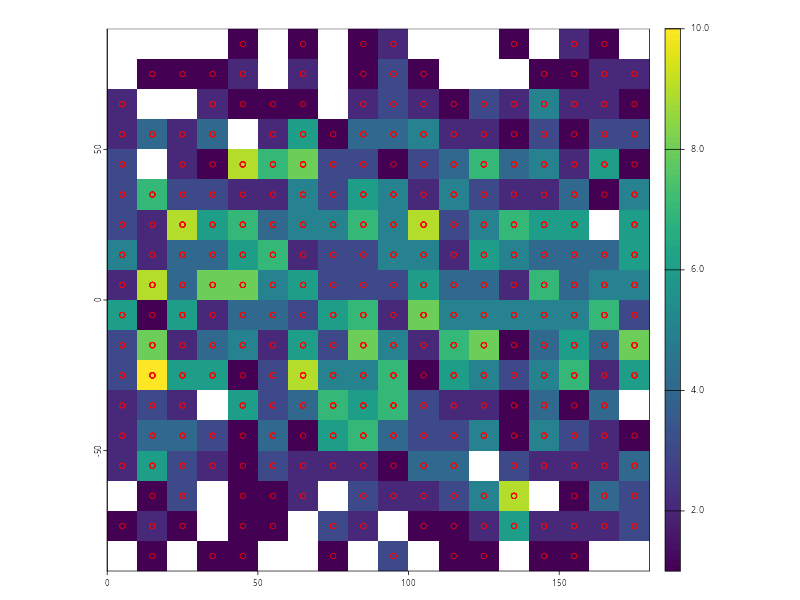

In [9]:
x <- rasterize(p, r, fun = sum)

plot(x)
points(p, col = "red")

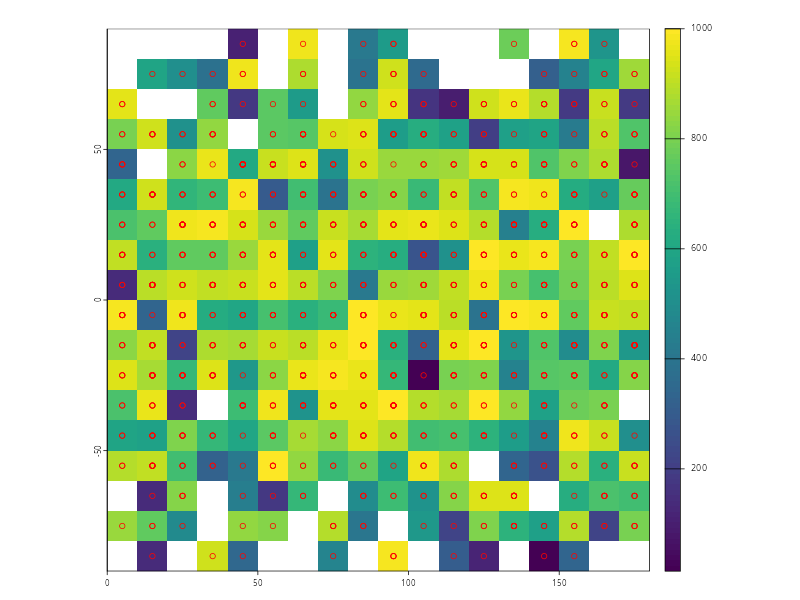

In [10]:
y <- rasterize(p, r, value = 1:nrow(p), fun = max)

plot(y)
points(p, col = "red")

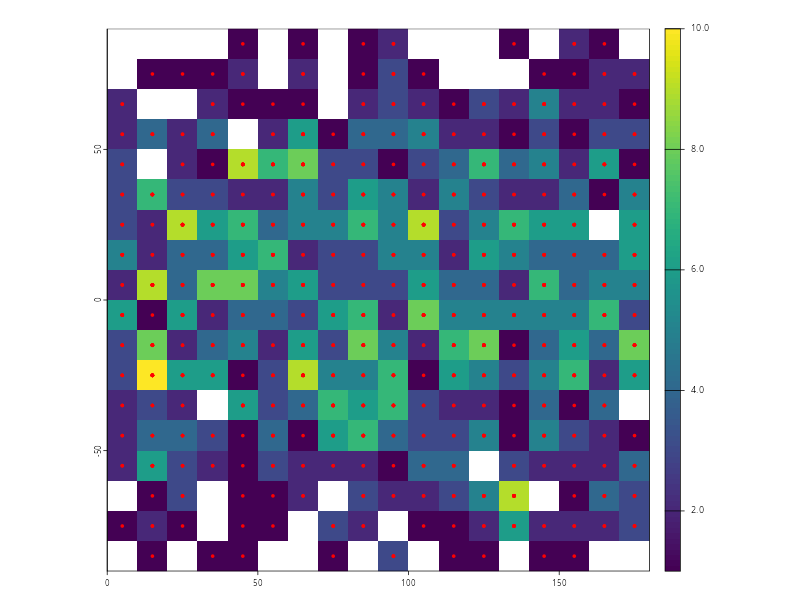

In [12]:
pv <- vect(p)
xv <- rasterize(pv, r, fun = sum)

plot(xv)
points(pv, col = "red")

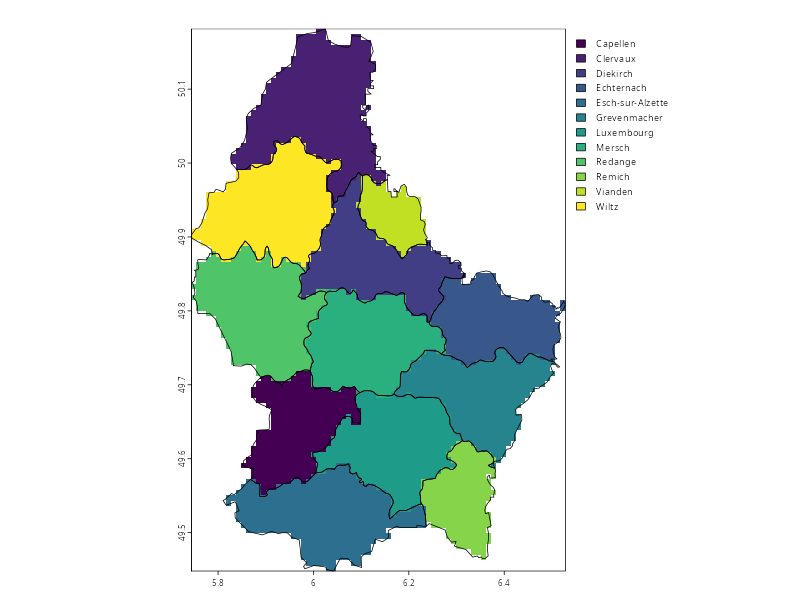

In [13]:
f <- system.file("ex/lux.shp", package = "terra")
v <- vect(f)
r <- rast(v, ncols = 75, nrows = 100)
z <- rasterize(v, r, "NAME_2")

plot(z)
lines(v)

## Changing the spatial extent or resolution

### `project`

**Change the coordinate reference system**

Change the coordinate reference system ("project") of a SpatVector, SpatRaster or a matrix with coordinates.

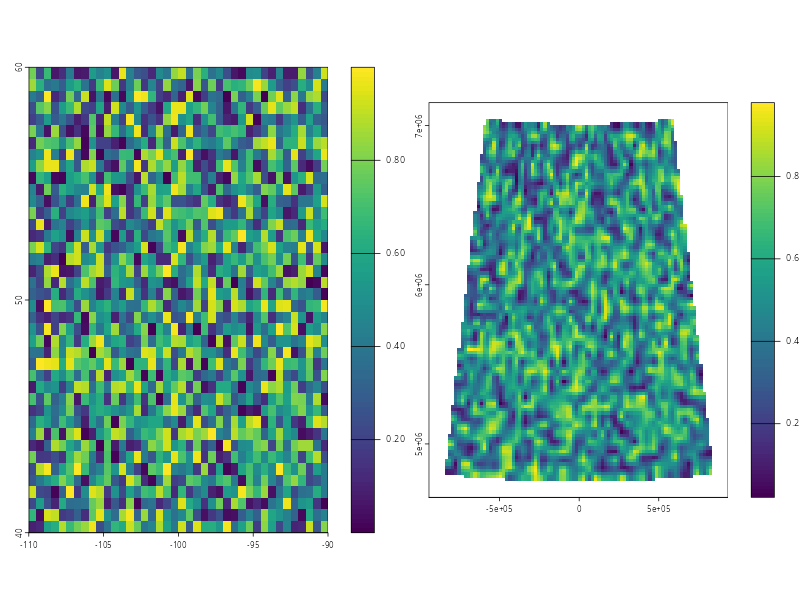

In [2]:
a <- rast(ncols = 40, nrows = 40,
          xmin = -110, xmax = -90,
          ymin = 40, ymax = 60, 
          crs = "+proj=longlat +datum=WGS84")
values(a) <- runif(ncell(a))
newcrs = "+proj=lcc +lat_1=48 +lat_2=33 +lon_0=-100 +datum=WGS84"
b <- rast(ncols = 94, nrows = 124,
          xmin = -944881, xmax = 935118,
          ymin = 4664377, ymax = 7144377,
          crs = newcrs)
w <- project(a, b)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(a)
plot(w)
par(opar)

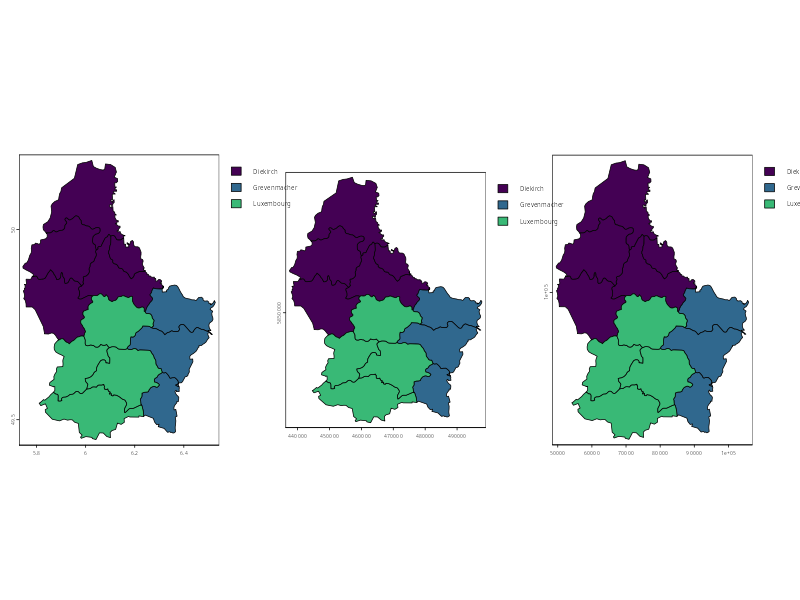

In [3]:
f <- system.file("ex/lux.shp", package = "terra")
v <- vect(f)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 3))
plot(v, "NAME_1")
plot(project(v, "+proj=moll"), "NAME_1")
plot(project(v, "EPSG:2169"), "NAME_1")
par(opar)

### `align`

**Align a SpatExtent**

Align an SpatExtent with a SpatRaster

This can be useful to create a new SpatRaster with the same origin and resolution as an existing SpatRaster. Do not use this to force data to match that really does not match (use e.g. `resample` or `aggregate`/`disagg` for this).

It is also possible to align a SpatExtent to a clean divisor.

In [66]:
r <- rast(nrows = 20, ncols = 20, xmin = 1, xmax = 11, ymin = -1, ymax = 11)
values(r) <- runif(ncell(r))
e <- ext(1.2, 11.2, -1.3, 10.7)
ea <- align(e, r)
eb <- align(e, 0.5)

print(ext(r))
print(e)
print(ea)
print(eb)

SpatExtent : 1, 11, -1, 11 (xmin, xmax, ymin, ymax)
SpatExtent : 1.2, 11.2, -1.3, 10.7 (xmin, xmax, ymin, ymax)
SpatExtent : 1, 11, -1.6, 10.4 (xmin, xmax, ymin, ymax)
SpatExtent : 1, 11.5, -1.5, 11 (xmin, xmax, ymin, ymax)


### `resample`

**Transfer values of a SpatRaster to another one with a different geometry**

`resample` transfers values between SpatRaster objects that do not align (have a different origin and/or resolution). See `project` to change the coordinate reference system (`crs`).

If the origin and extent of the input and output are the same, you should consider using these other functions instead: `aggregate`, `disagg`, `extend` or `crop`.

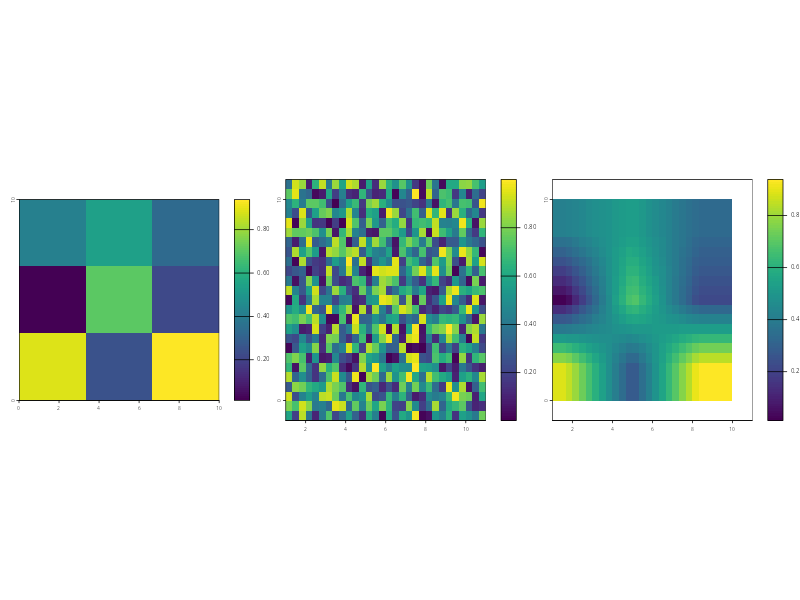

In [52]:
r <- rast(nrows =  3, ncols =  3, xmin = 0, xmax = 10, ymin =  0, ymax = 10)
values(r) <- runif(ncell(r))
s <- rast(nrows = 25, ncols = 30, xmin = 1, xmax = 11, ymin = -1, ymax = 11)
values(s) <- runif(ncell(s))
x <- resample(r, s, method = "bilinear")

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 3))
plot(r)
plot(s)
plot(x)
par(opar)

### `aggregate`

**Aggregate raster or vector data**

Aggregate a SpatRaster to create a new SpatRaster with a lower resolution (larger cells). Aggregation groups rectangular areas to create larger cells. The value for the resulting cells is computed with a user-specified function.

You can also aggregate ("dissolve") a SpatVector. This either combines all geometries into one geometry, or it combines the geometries that have the same value for the variable(s) specified with argument by.

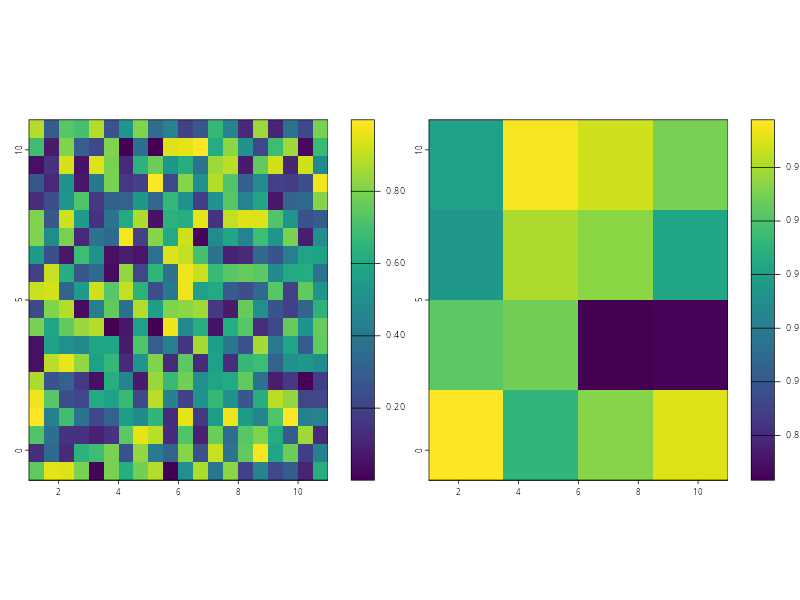

In [ ]:
r <- rast(nrows = 20, ncols = 20, xmin = 1, xmax = 11, ymin = -1, ymax = 11)
values(r) <- runif(ncell(r))
ra <- aggregate(r, fact = 5, fun = max)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r)
plot(ra)
par(opar)

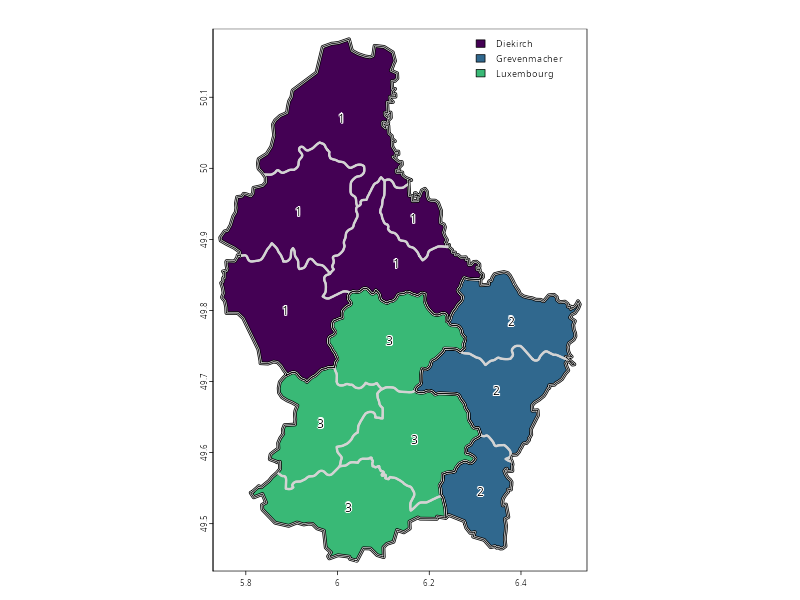

In [ ]:
f <- system.file("ex/lux.shp", package = "terra")
v <- vect(f)
va <- aggregate(v, "ID_1")

plot(va, "NAME_1", lwd = 5, plg = list(x = "topright"), mar = rep(2, 4))
lines(v, lwd = 3, col = "light gray")
lines(va)
text(v, "ID_1", halo = TRUE)

### `disagg`

**Disaggregate raster cells or vector geometries**

_SpatRaster:_ Create a SpatRaster with a higher resolution (smaller cells). The values in the new SpatRaster are the same as in the larger original cells.

_SpatVector:_ Separate multi-objects (points, lines, polygons) into single objects; or further into segments (for lines or polygons).

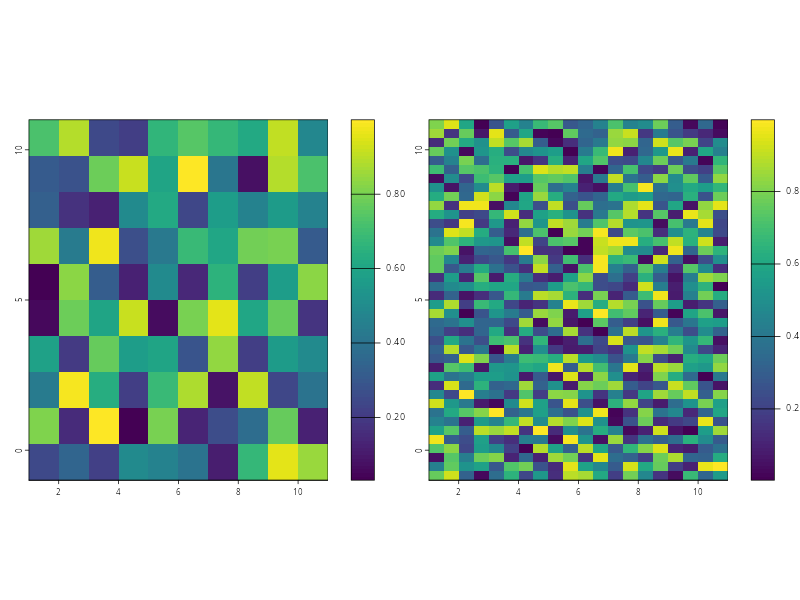

In [29]:
r <- rast(nrows = 10, ncols = 10, xmin = 1, xmax = 11, ymin = -1, ymax = 11)
values(r) <- runif(ncell(r))
rd <- disagg(r, fact = c( 4, 2))
values(rd) <- runif(ncell(rd))

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r)
plot(rd)
par(opar)

### `extend`

**Extend**

Enlarge the spatial extent of a SpatRaster. See crop if you (also) want to remove rows or columns.

Note that you can only enlarge SpatRasters with entire rows and columns. Therefore, the extent of the output SpatRaster may not be exactly the same as the requested. Depending on argument snap it may be a bit smaller or larger.

You can also enlarge a SpatExtent with this method, or with an algebraic notation (see examples)

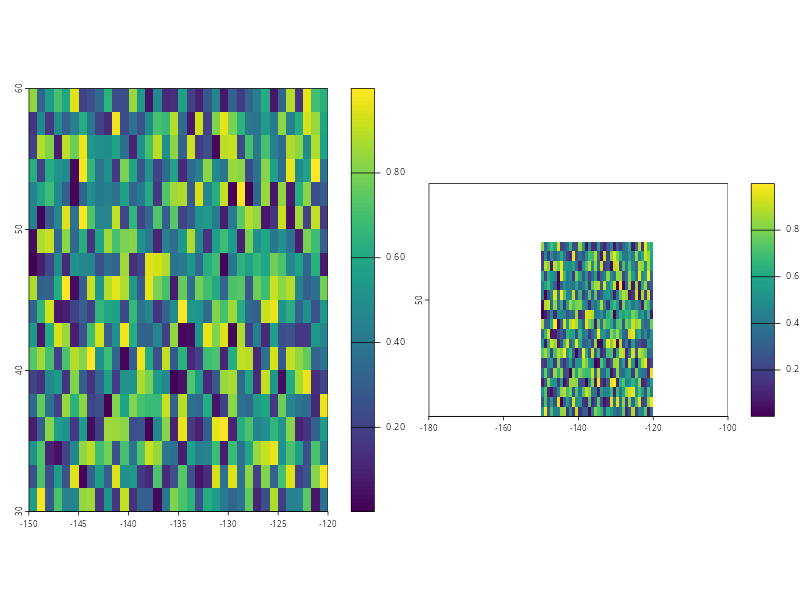

In [37]:
r <- rast(xmin = -150, xmax = -120, ymin = 30, ymax = 60, ncols = 36, nrows = 18)
values(r) <- runif(ncell(r))
e <- ext(-180, -100, 40, 70)
re <- extend(r, e)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r)
plot(re)
par(opar)

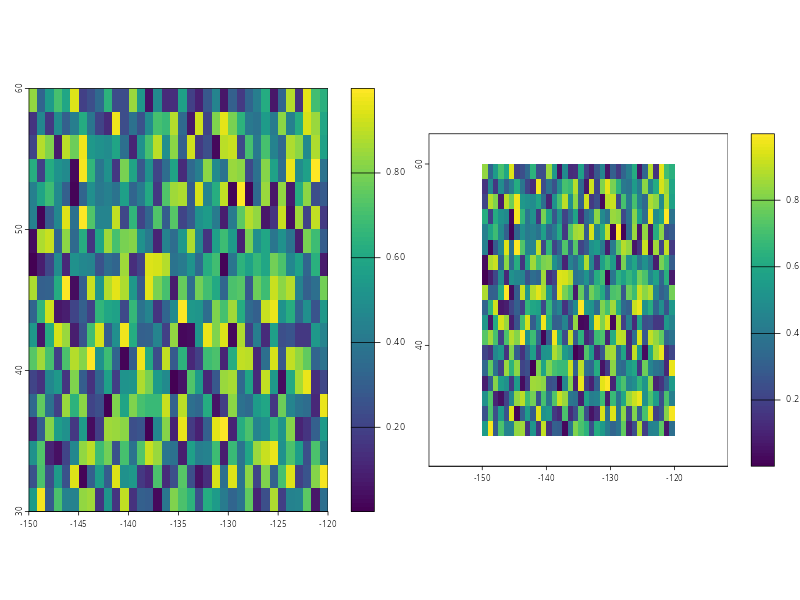

In [38]:
re2 <- extend(r, c(2,10))

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r)
plot(re2)
par(opar)

### `crop`

**Cut out a geographic subset**

Cut out a part of a SpatRaster or SpatVector.

You can crop a SpatRaster with a SpatExtent, or with another object from which an extent can be obtained. Note that the SpatRaster returned may not have the exactly the same extent as the SpatExtent supplied because you can only select entire cells (rows and columns), and you cannot add new areas. See methods like `resample` and `disagg` to force SpatRasters to align and `extend` to add rows and/or columns.

You can only crop rectangular areas of a SpatRaster, but see argument `mask = TRUE` for setting cell values within SpatRaster to NA; or use the `mask` method after crop for additional masking options.

You can crop a SpatVector with another SpatVector. If these are not polygons, the minimum convex hull is used. Unlike with intersect the geometries and attributes of y are not transferred to the output. You can also crop a SpatVector with a rectangle (SpatRaster, SpatExtent).

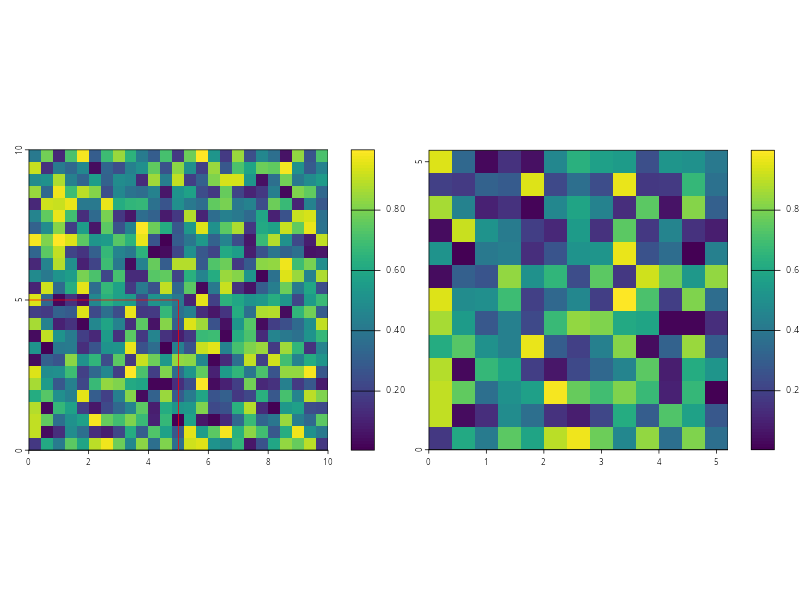

In [45]:
r <- rast(xmin = 0, xmax = 10, ymin = 0, ymax = 10, nrows = 25, ncols = 25)
values(r) <- runif(ncell(r))
e <- ext(-5, 5, -5, 5)
rc <- crop(r, e)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r); lines(e, col = "red")
plot(rc)
par(opar)

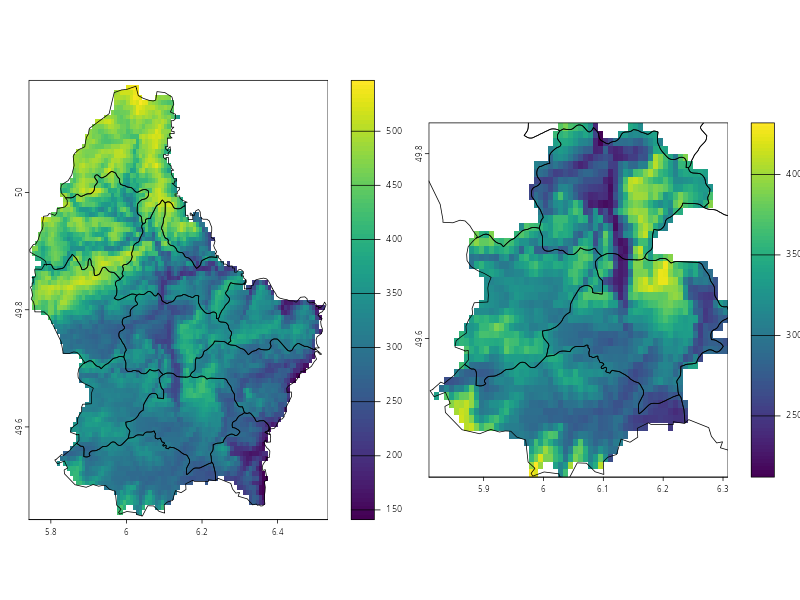

In [47]:
f <- system.file("ex/elev.tif", package = "terra")
r <- rast(f)
f <- system.file("ex/lux.shp", package = "terra")
v <- vect(f)
cm <- crop(r, v[9:12,], mask = TRUE)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r); lines(v)
plot(cm); lines(v)
par(opar)

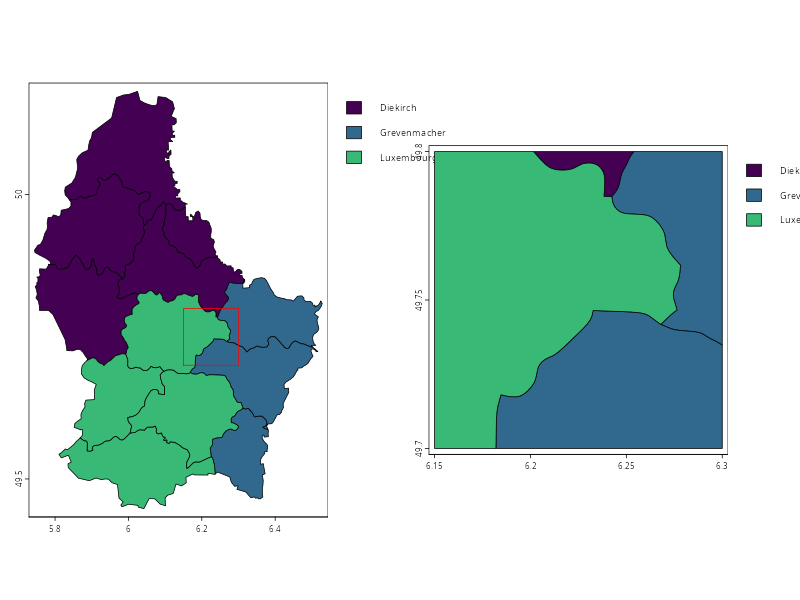

In [50]:
f <- system.file("ex/lux.shp", package="terra")
v <- vect(f)
e <- ext(6.15, 6.3, 49.7, 49.8)
x <- crop(v, e)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(v, "NAME_1"); lines(e, col = "red")
plot(x, "NAME_1")
par(opar)

### `mosaic`

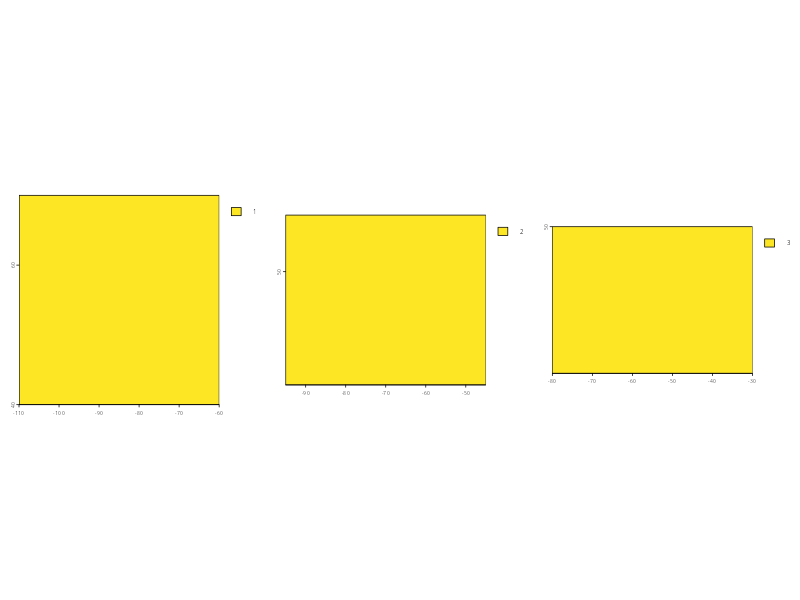

In [16]:
x <- rast(xmin = -110, xmax = -60, ymin = 40, ymax = 70, res = 1, vals = 1)
y <- rast(xmin =  -95, xmax = -45, ymax = 60, ymin = 30, res = 1, vals = 2)
z <- rast(xmin =  -80, xmax = -30, ymax = 50, ymin = 20, res = 1, vals = 3)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 3))
plot(x)
plot(y)
plot(z)
par(opar)

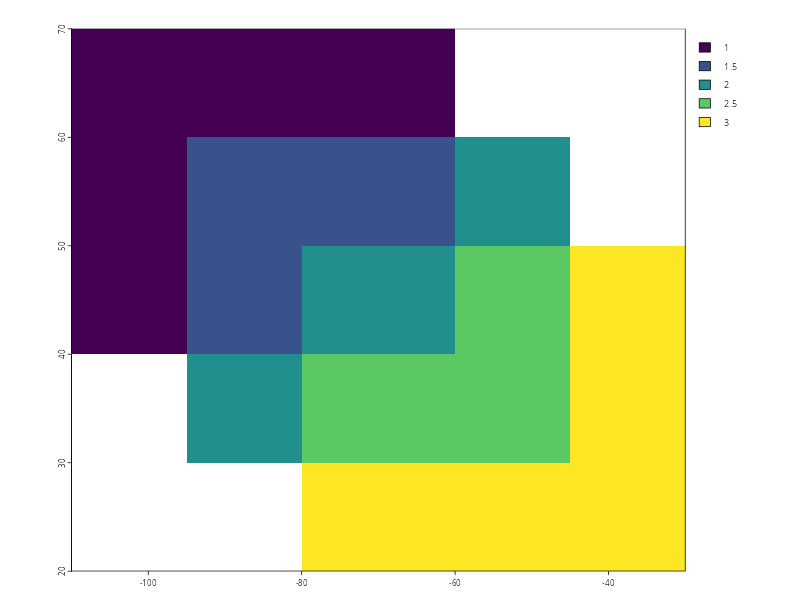

In [17]:
m1 <- mosaic(x, y, z)

plot(m1)

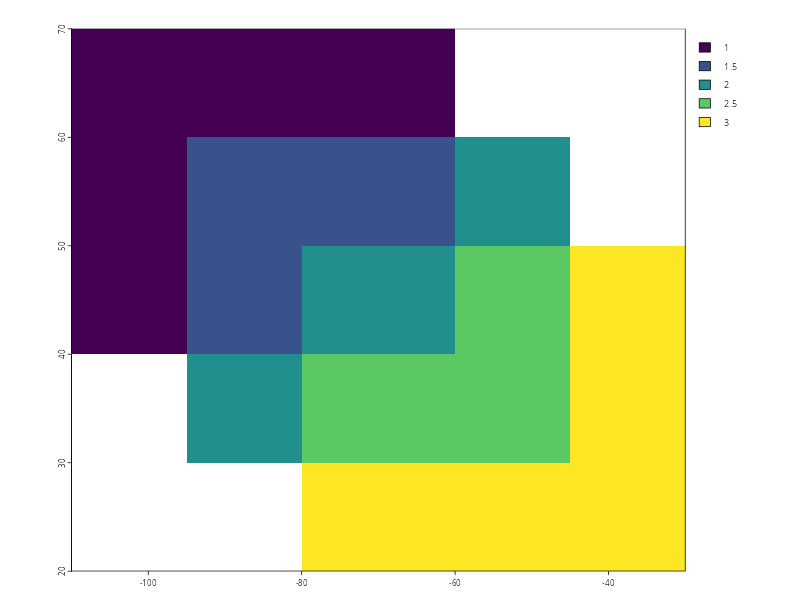

In [18]:
m2 <- mosaic(z, y, x)

plot(m2)

class       : SpatRasterCollection 
length      : 3 
nrow        : 30, 30, 30 
ncol        : 50, 50, 50 
nlyr        :  1,  1,  1 
extent      : -110, -30, 20, 70  (xmin, xmax, ymin, ymax)
crs (first) : lon/lat WGS 84 (CRS84) (OGC:CRS84) 


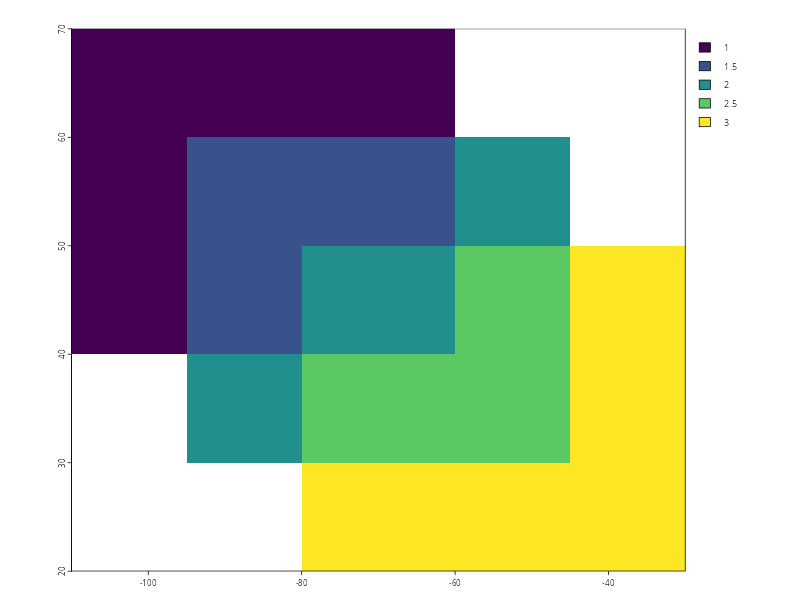

In [21]:
rlist <- list(x, y, z)
rsrc <- sprc(rlist)
m <- mosaic(rsrc)

print(rsrc)
plot(m)

## Local (cell-based) methods

### `mask`

**Mask values in a SpatRaster or SpatVector**

If `x` is a SpatRaster: Create a new SpatRaster that has the same values as SpatRaster `x`, except for the cells that are NA (or other maskvalue) in another SpatRaster (the 'mask'), or the cells that are not covered by a SpatVector or SpatExtent. These cells become NA (or another updatevalue).

If `x` is a SpatVector or SpatExtent: Select geometries of `x` that intersect, or not intersect, with the geometries of `y`.

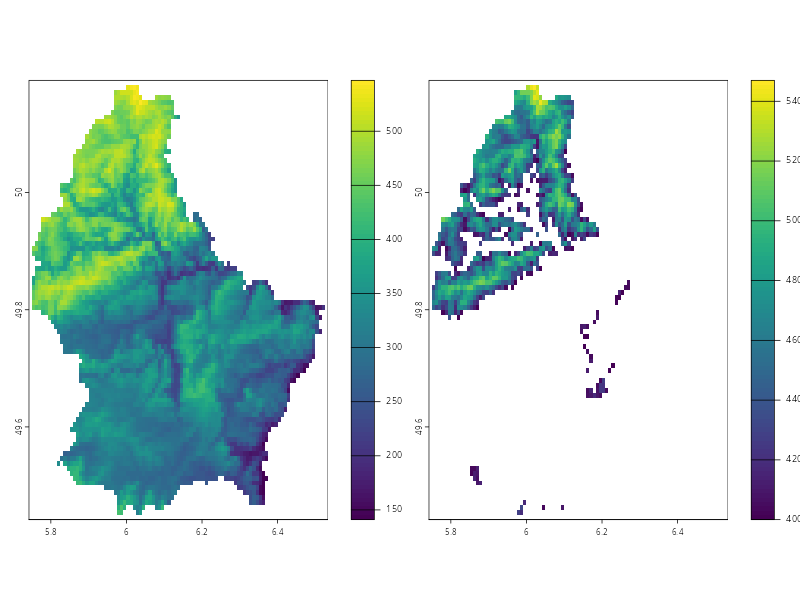

In [109]:
f <- system.file("ex/elev.tif", package = "terra")
r <- rast(f)
msk <- ifel(r < 400, NA, 1)
m <- mask(r, msk)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r)
plot(m)
par(opar)

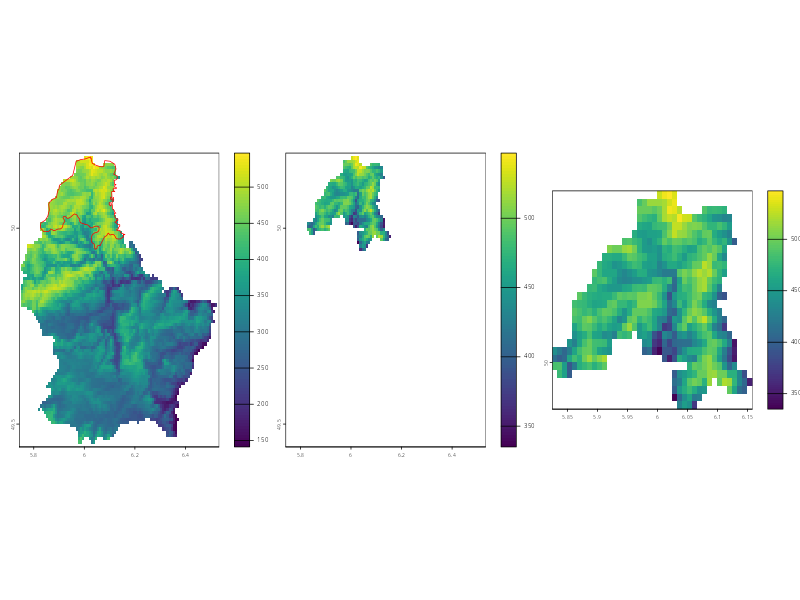

In [113]:
f <- system.file("ex/lux.shp", package = "terra")
v <- vect(f)[1,]
mv1 <- mask(r, v)
mv2 <- crop(r, v, mask = TRUE)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 3))
plot(r); lines(v, col = "red")
plot(mv1)
plot(mv2)
par(opar)

### `clamp`

**Clamp values**

Clamp values to a minimum and maximum value. That is, all values below a lower threshold value and above the upper threshold value become either NA, or, if `values=TRUE`, become the threshold value

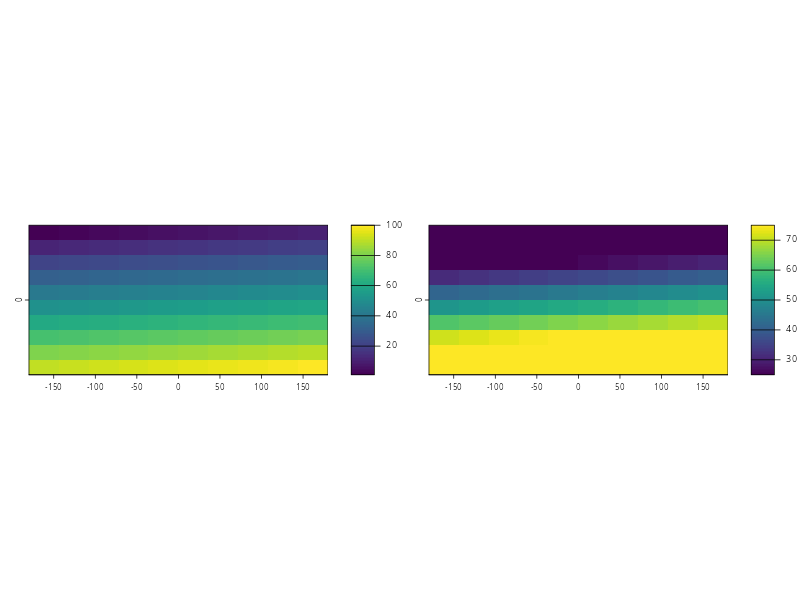

In [108]:
r <- rast(ncols=10, nrows=10)
values(r) <- 1:ncell(r)
rc <- clamp(r, 25, 75) 

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r)
plot(rc)
par(opar)

### `approximate`

**Estimate values for cell values that are NA by interpolating between layers**

Uses the stats function `approx` to estimate values for cells that are NA by interpolation across layers. Layers are considered equidistant, unless argument z is used, or `time(x)` returns values that are not NA, in which case these values are used to determine distance between layers.

For estimation based on neighboring cells see `focal`

In [89]:
r <- rast(ncols = 5, nrows = 5)
r1 <- setValues(r, runif(ncell(r)))
r2 <- setValues(r, runif(ncell(r)))
r3 <- setValues(r, runif(ncell(r)))
r4 <- setValues(r, runif(ncell(r)))
r5 <- setValues(r, NA)
r6 <- setValues(r, runif(ncell(r)))
r1[6:10] <- NA
r2[5:15] <- NA
r3[8:25] <- NA
s <- c(r1, r2, r3, r4, r5, r6)
names(s) <- c("r1", "r2", "r3", "r4", "r5", "r6")
s[1:5] <- NA

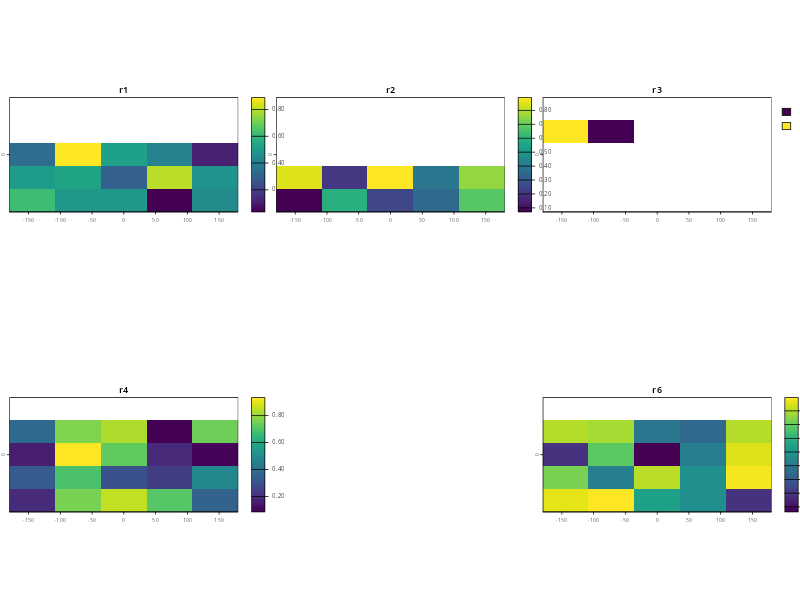

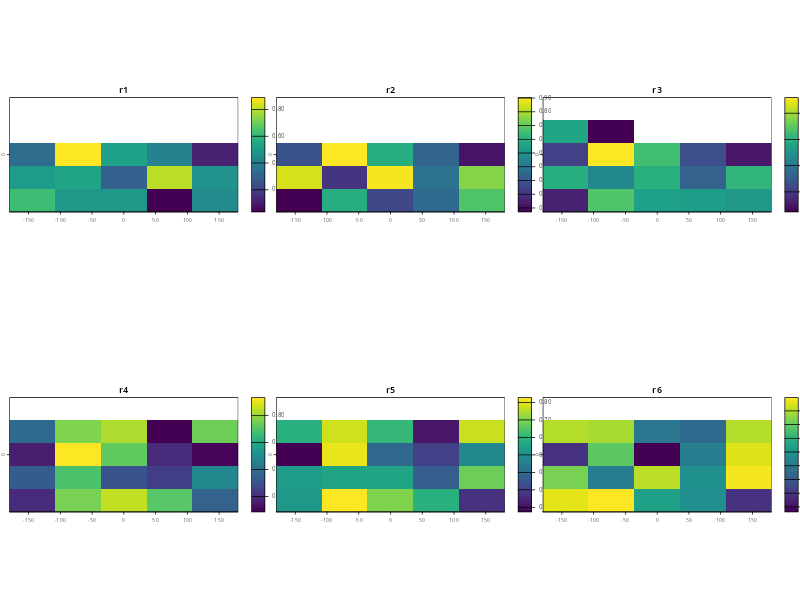

In [90]:
x1 <- approximate(s)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 3))
plot(s)
plot(x1)
par(opar)

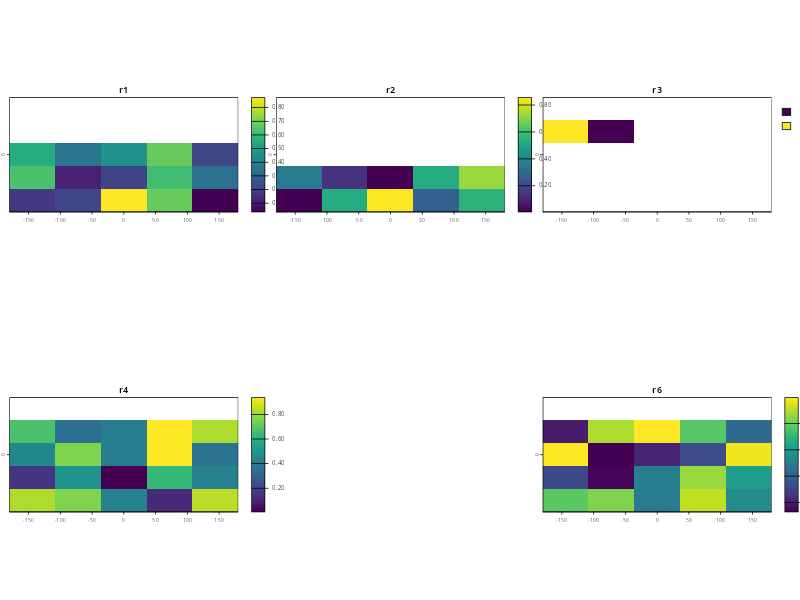

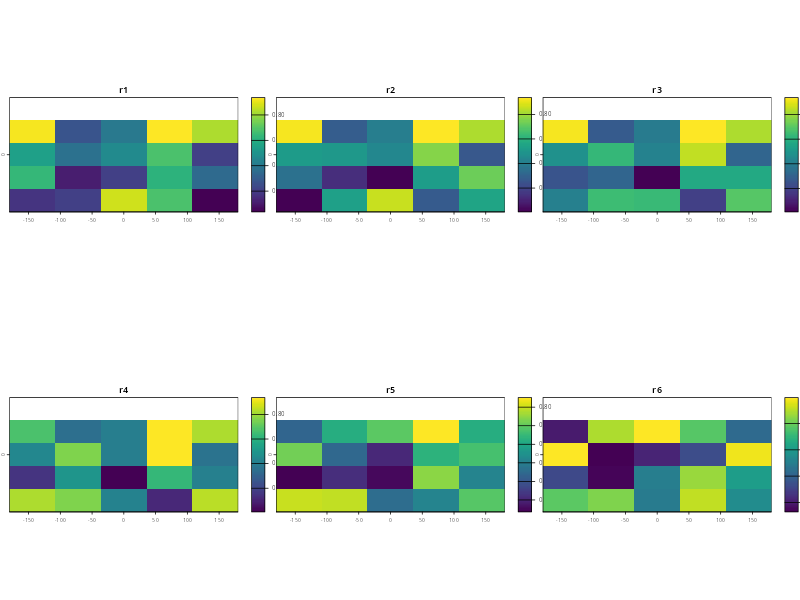

In [76]:
x2 <- approximate(s, rule = 2)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 3))
plot(s)
plot(x2)
par(opar)

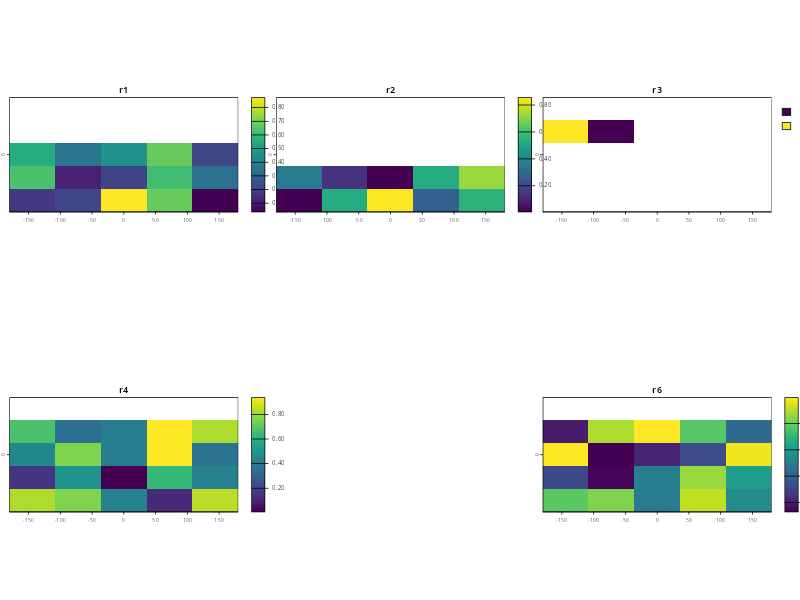

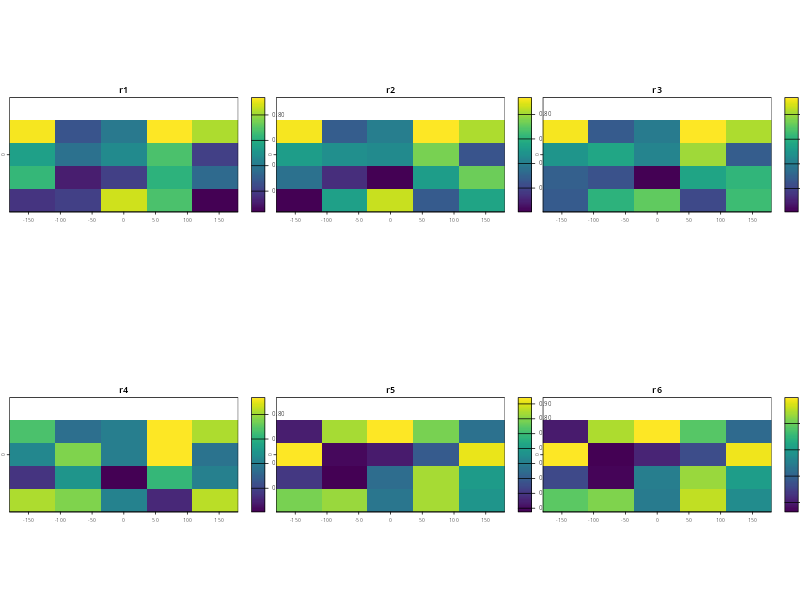

In [77]:
x3 <- approximate(s, rule = 2, z = c(1, 2, 3, 5, 14, 15))

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 3))
plot(s)
plot(x3)
par(opar)

### `roll`

**Rolling (moving) functions**

Compute "rolling" or "moving" values, such as the "rolling average" for each cell in a SpatRaster.

See `focal` for spatially moving averages and similar computations. And see `cumsum` and other cum* functions to compute cumulate values.

In [115]:
r <- rast(ncol = 2, nrow = 2, nlyr = 10, vals = 1)
r[1, 2] <- 2
r[2, 2] <- 4

rr1 <- roll(r, n = 3, "sum", "from", na.rm = FALSE)
rr2 <- roll(r, n = 3, "sum", "from", na.rm = TRUE)
rr3 <- roll(r, n = 3, "sum", "from", circular = TRUE)
rr4 <- roll(r, n = 3, "sum", "to", na.rm = TRUE)
rr5 <- roll(r, n = 3, "sum", "around", circular = TRUE)

### `classify`

**Classify (or reclassify) cell values**

Classify values of a SpatRaster. The function (re-)classifies groups of values to other values.

The classification is done based on the argument `rcl`. You can classify ranges by specifying a three-column matrix "from-to-becomes" or change specific values by using a two-column matrix "is-becomes". You can also supply a vector with "cuts" or the "number of cuts".

With "from-to-becomes" or "is-becomes" classification is done in the row order of the matrix. Thus, if there are overlapping ranges or values, the first time a number is within a range determines the reclassification value.

With "cuts" the values are sorted, so that the order in which they are provided does not matter.

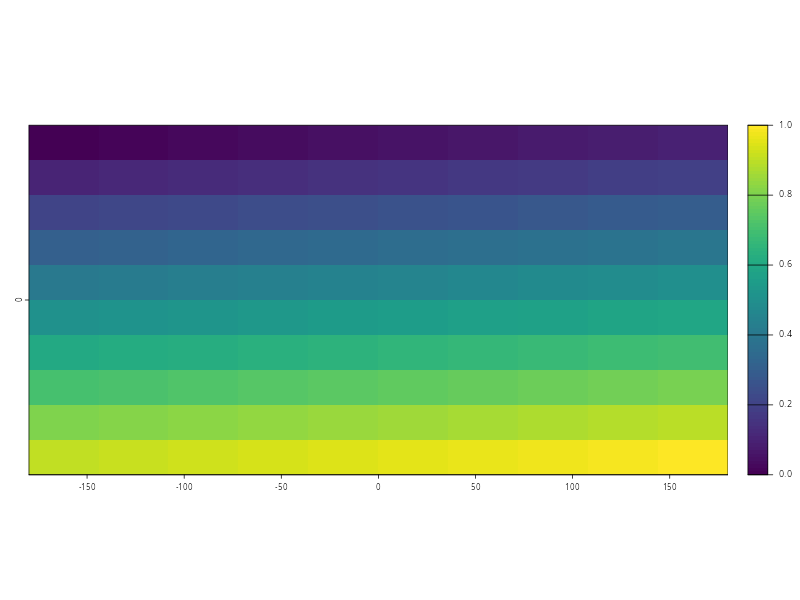

In [99]:
r <- rast(ncols = 10, nrows = 10)
values(r) <- (0:99)/99

plot(r)

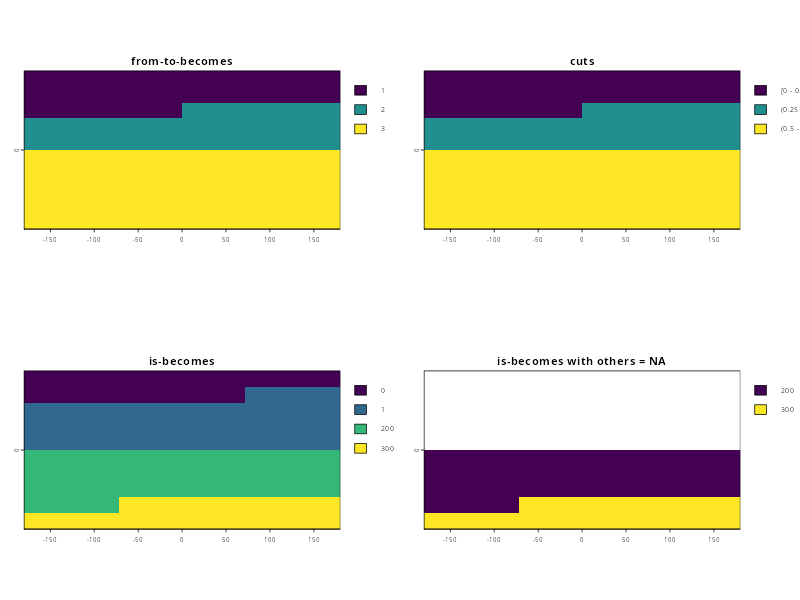

In [101]:
m <- c(0, 0.25, 1,
       0.25, 0.5, 2,
       0.5, 1, 3)
rclmat <- matrix(m, ncol = 3, byrow = TRUE)
rc1 <- classify(r, rclmat, include.lowest = TRUE)
rc2 <- classify(r, c(0, 0.25, 0.5, 1), include.lowest = TRUE, brackets = TRUE)
x <- round(r*3)
y <- classify(x, cbind(0, NA))
m <- rbind(c(2, 200), c(3, 300))
rcx1 <- classify(x, m)
rcx2 <- classify(x, m, others = NA)

opar <- par(no.readonly = TRUE)
par(mfrow = c(2, 2))
plot(rc1, main = "from-to-becomes")
plot(rc2, main = "cuts")
plot(rcx1, main = "is-becomes")
plot(rcx2, main = "is-becomes with others = NA")
par(opar)

### `segregate`

**segregate**

Create a SpatRaster with a layer for each class (value, or subset of the values) in the input SpatRaster. For example, if the input has vegetation types, this function will create a layer (presence/absence; dummy variable) for each of these classes.

This is called "one-hot encoding" or "dummy encoding" (for a dummy encoding scheme you can remove (any) one of the output layers as it is redundant).

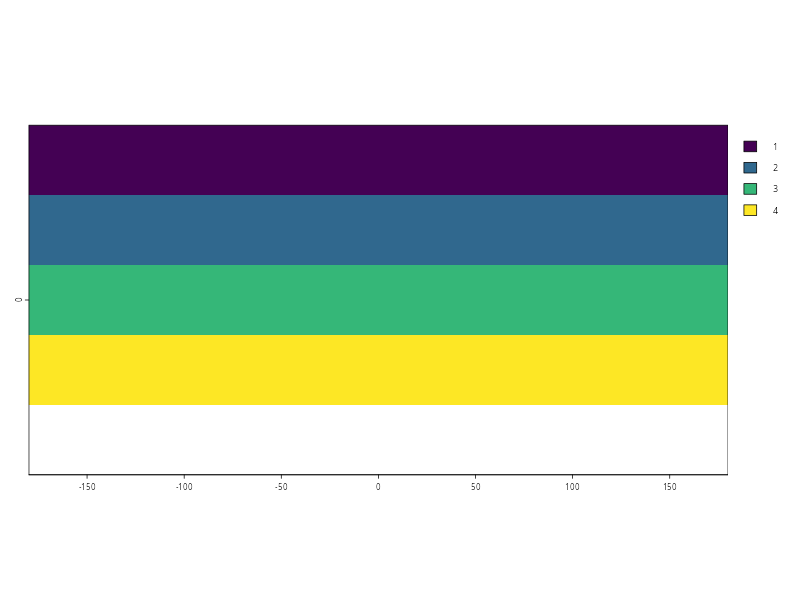

In [ ]:
r <- rast(nrows = 5, ncols = 5)
values(r) <- rep(c(1:4, NA), each = 5)

plot(r)

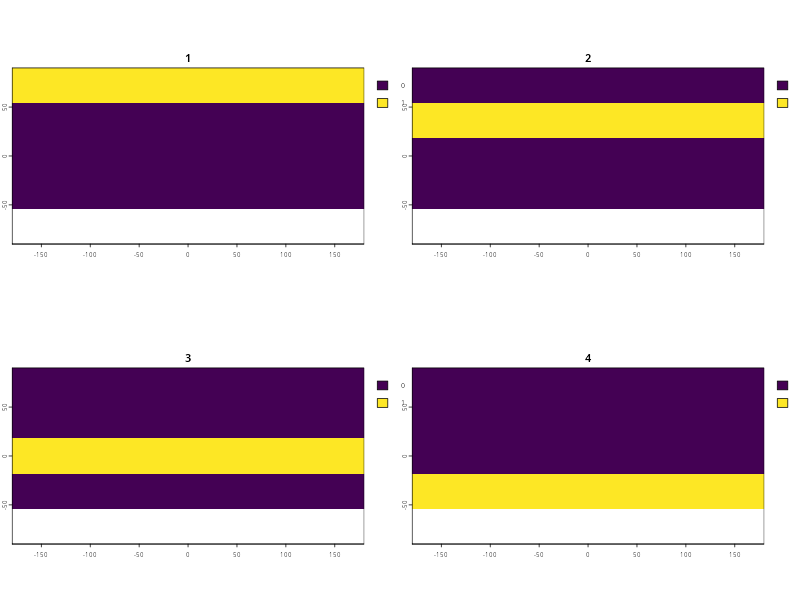

In [106]:
b <- segregate(r)
plot(b)

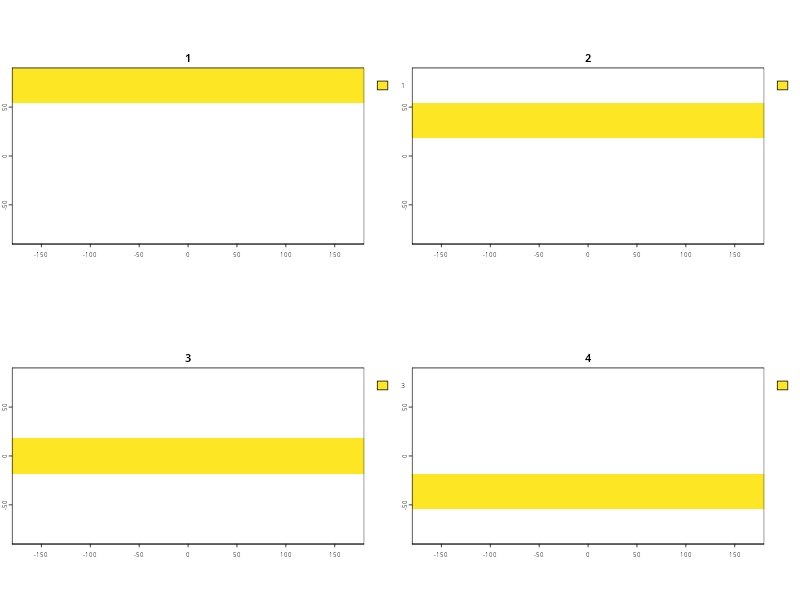

In [107]:
bb <- segregate(r, keep = TRUE, other = NA)
plot(bb)

## Exploratory analysis and dimensional reduction

### `princomp`

**SpatRaster PCA with princomp**

Compute principal components for SpatRaster layers. This method can use all values to compute the principal components, even for very large rasters. This is because it computes the covariance matrix by processing the data in chunks, if necessary, using `layerCor`. The population covariance is used (not the sample, with n-1 denominator, covariance).

Alternatively, you can specify `maxcell` or sample raster values to a `data.frame` to speed up calculations for very large rasters (see the examples below).

See `prcomp` for an alternative method that has higher numerical accuracy, but is slower, and for very large rasters can only be accomplished with a sample since all values must be read into memory.

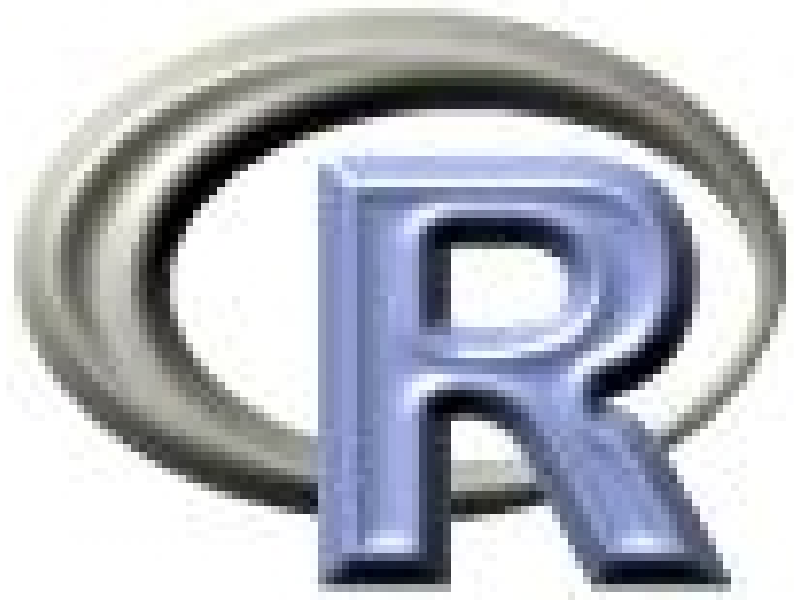

In [4]:
f <- system.file("ex/logo.tif", package = "terra")
r <- rast(f)

plot(r)

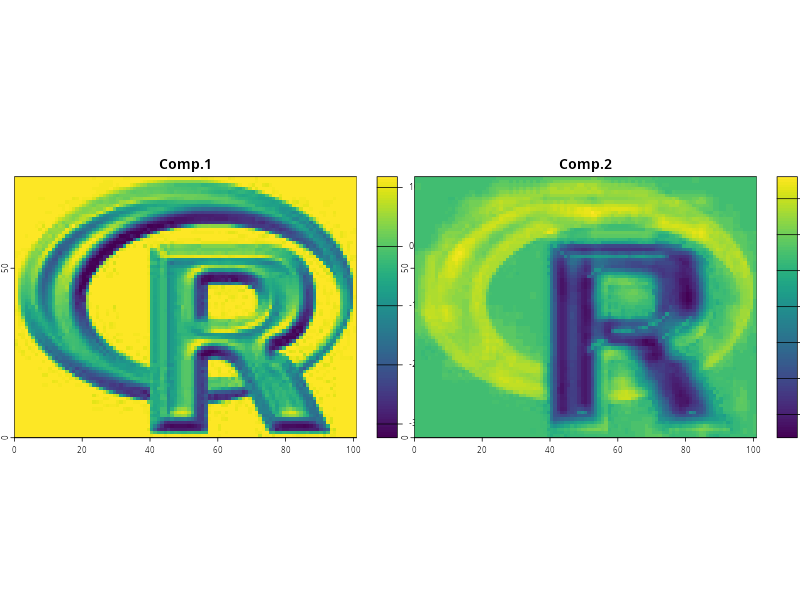

In [5]:
pca <- princomp(r)
p <- predict(r, pca, index=1:2)

plot(p)

### `prcomp`

**SpatRaster PCA with prcomp**

Compute principal components for SpatRaster layers. This method may be preferred to `princomp` for its greater numerical accuracy. However, it is slower and for very large rasters it can only be done with a sample. This may be good enough but see `princomp` if you want to use all values. Unlike `princomp`, in this method the sample variances are used with n-1 as the denominator.

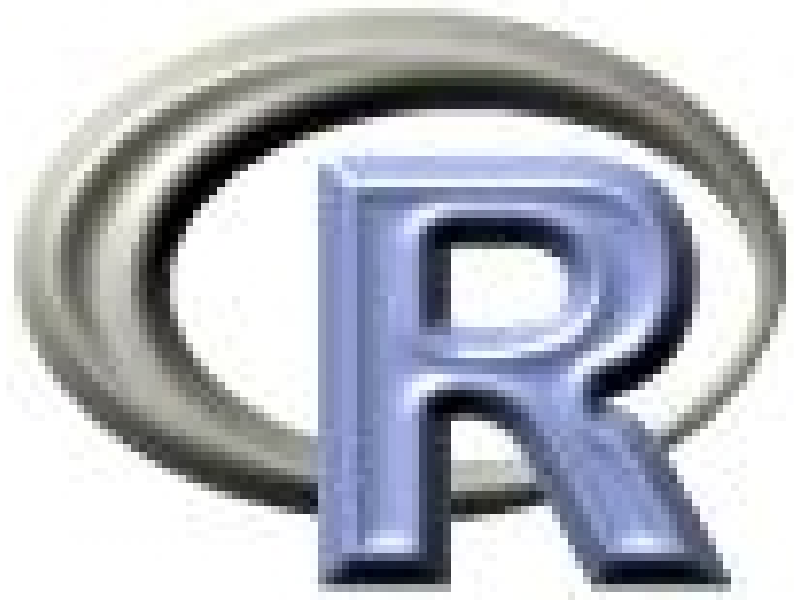

In [6]:
f <- system.file("ex/logo.tif", package = "terra")
r <- rast(f)

plot(r)

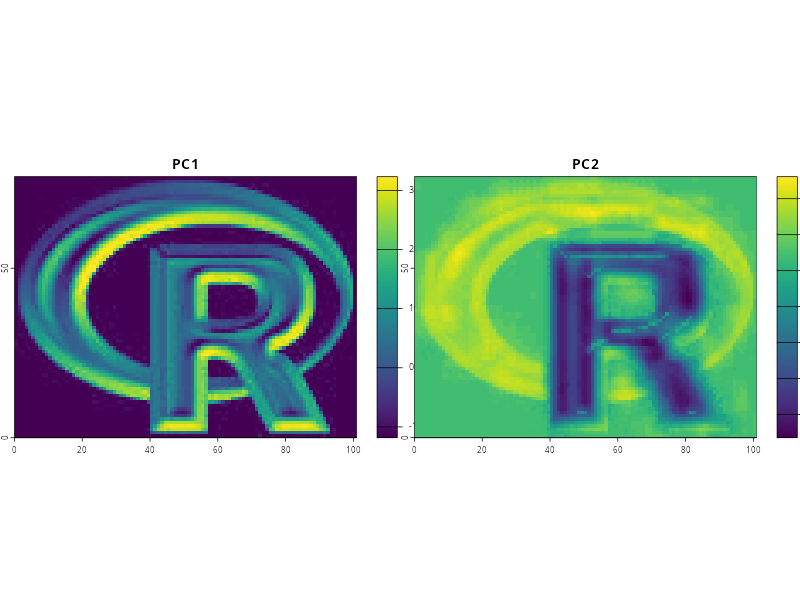

In [7]:
pca <- prcomp(r)
p <- predict(r, pca, index = 1:2)

plot(p)

### `k_means`

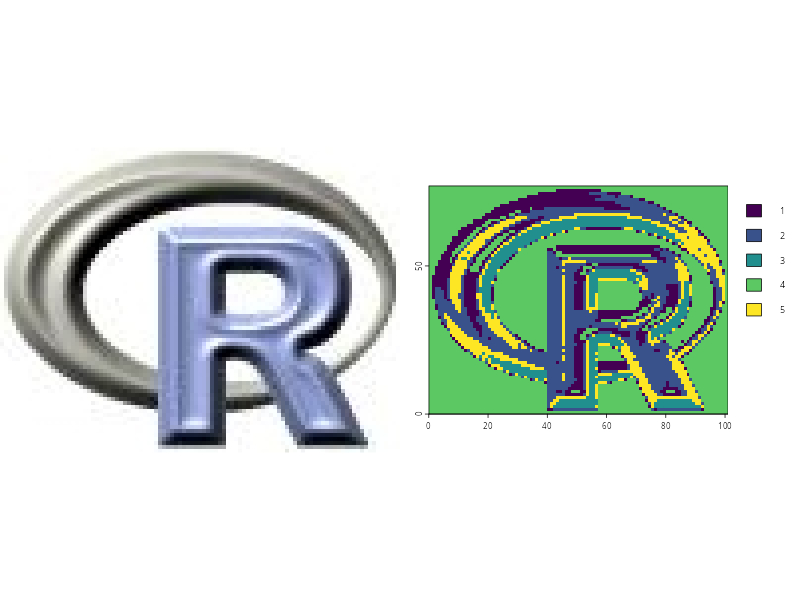

In [25]:
f <- system.file("ex/logo.tif", package = "terra")
r <- rast(f)
km <- k_means(r, centers = 5)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r)
plot(km)
par(opar)

## Zonal and global methods

### `global`

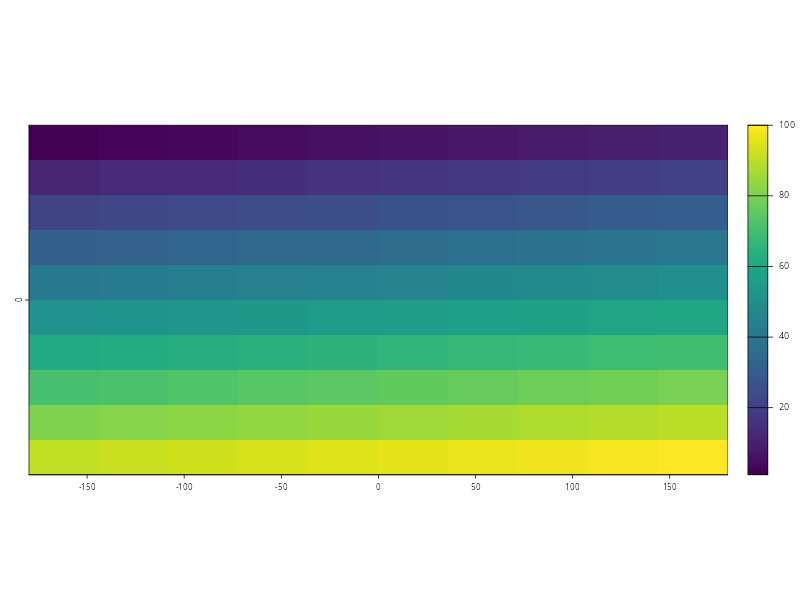

In [26]:
r <- rast(ncols = 10, nrows = 10)
values(r) <- 1:ncell(r)

plot(r)

In [33]:
global(r, "sum") |> print()

       sum
lyr.1 5050


In [34]:
global(r, "mean", na.rm = TRUE) |> print()

      mean
lyr.1 50.5


In [35]:
x <- c(r, r/10)
global(x, c("sum", "mean", "sd"), na.rm = TRUE) |> print()

         sum  mean        sd
lyr.1   5050 50.50 29.011492
lyr.1.1  505  5.05  2.901149


In [36]:
global(x, function(i) min(i) / max(i)) |> print()

        global
lyr.1     0.01
lyr.1.1   0.01


### `summary`

     lyr.1             lyr.2             lyr.3        
 Min.   :0.01339   Min.   :0.01308   Min.   :0.02779  
 1st Qu.:0.32308   1st Qu.:0.28440   1st Qu.:0.18947  
 Median :0.48781   Median :0.51860   Median :0.37810  
 Mean   :0.52076   Mean   :0.51569   Mean   :0.43403  
 3rd Qu.:0.77171   3rd Qu.:0.72570   3rd Qu.:0.63596  
 Max.   :0.99191   Max.   :0.99268   Max.   :0.98156  


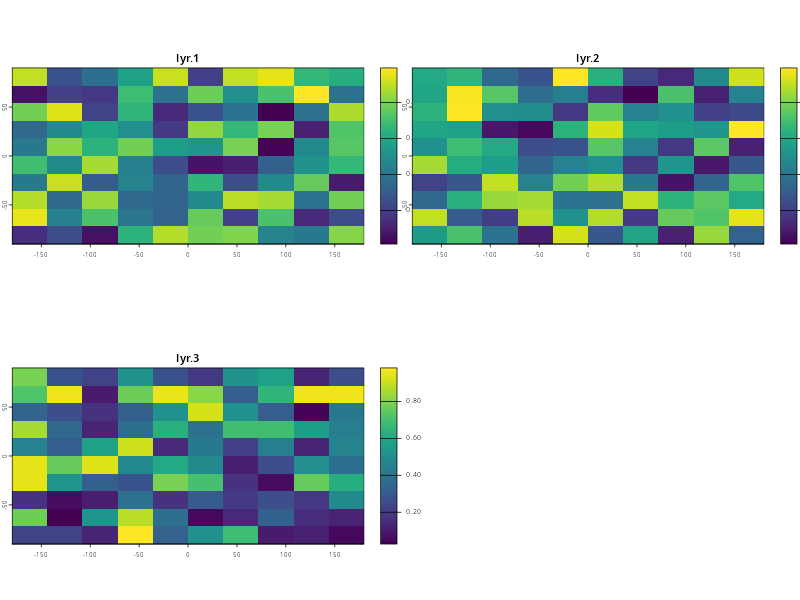

In [84]:
set.seed(0)
r <- rast(nrows = 10, ncols = 10, nlyrs = 3)
values(r) <- runif(nlyr(r) * ncell(r))

summary(r) |> print()
plot(r)

### `zonal`

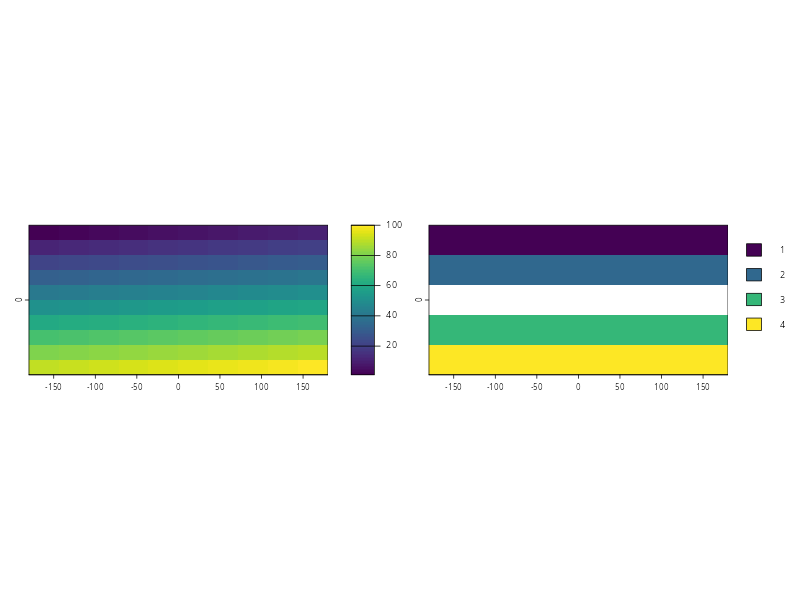

In [57]:
r <- rast(ncols = 10, nrows = 10)
values(r) <- 1:ncell(r)
z <- rast(r)
values(z) <- rep(c(1:2, NA, 3:4), each = 20)
names(z) <- "zone"

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r)
plot(z)
par(opar)

In [58]:
zonal(r, z, "sum", na.rm = TRUE) |> print()

  zone lyr.1
1    1   210
2    2   610
3    3  1410
4    4  1810


In [59]:
w <- init(r, "col")
zonal(r, z, w = w, "mean", na.rm = TRUE) |> print()

  zone lyr.1
1    1    12
2    2    32
3    3    72
4    4    92


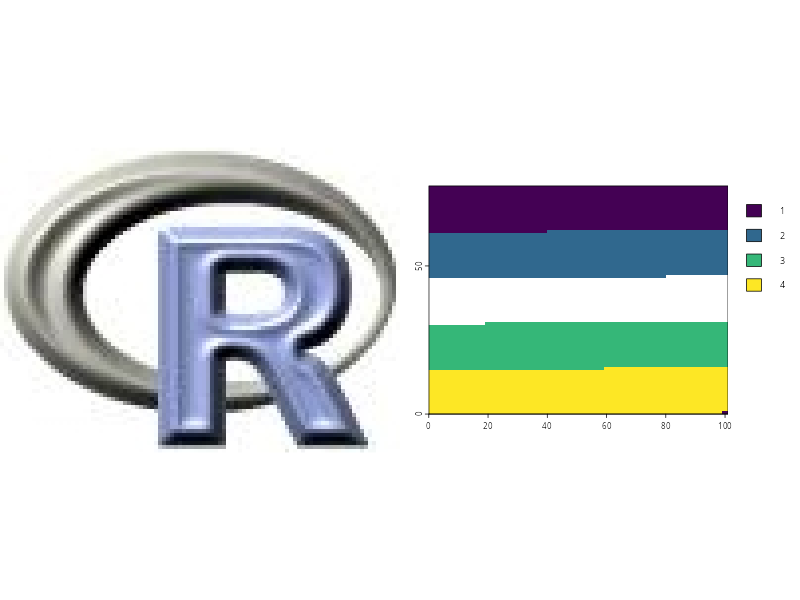

In [61]:
r <- rast(system.file("ex/logo.tif", package = "terra")) 
z <- rast(r, 1)
names(z) <- "zone"
values(z) <- rep(c(1:2, NA, c(3:4)), each = ncell(r) / 5, length.out = ncell(r))

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r)
plot(z)
par(opar)

In [62]:
zonal(r, z, "mean", na.rm = TRUE) |> print()

  zone      red    green     blue
1    1 197.9486 198.0103 193.5556
2    2 173.2219 176.7717 185.2585
3    3 168.2952 172.6232 184.6939
4    4 193.5859 197.0019 206.5717


class       : SpatRaster 
dimensions  : 77, 101, 3  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 0, 101, 0, 77  (xmin, xmax, ymin, ymax)
coord. ref. : Cartesian (Meter) 
source(s)   : memory
names       :      red,    green,     blue 
min values  : 168.2952, 172.6232, 184.6939 
max values  : 197.9486, 198.0103, 206.5717 


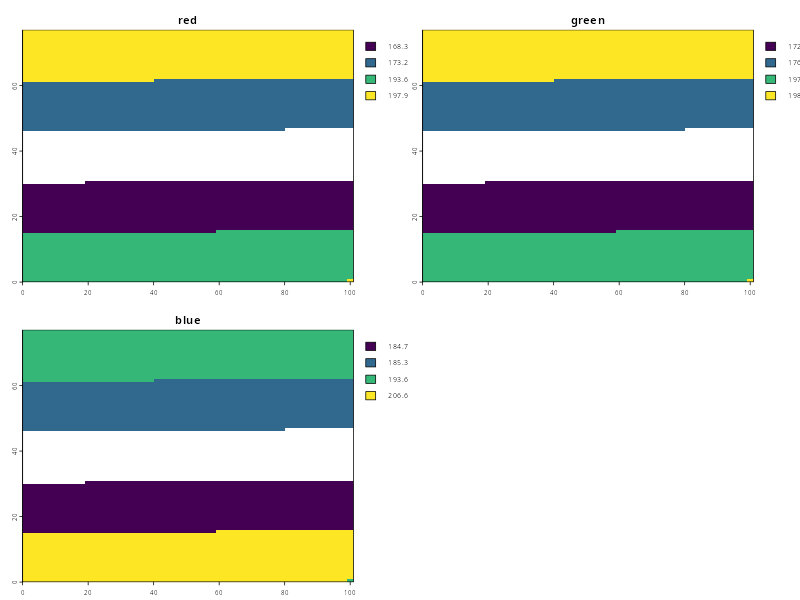

In [64]:
zr <- zonal(r, z, "mean", na.rm = TRUE, as.raster = TRUE)

print(zr)
plot(zr)

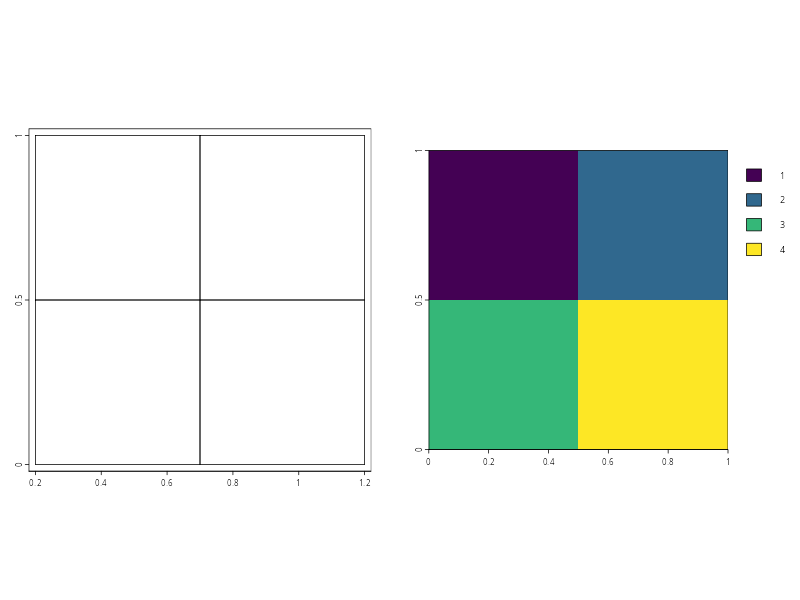

In [66]:
x <- rast(ncol = 2,nrow = 2, vals = 1:4,
          xmin = 0, xmax = 1, ymin = 0, ymax = 1,
          crs = "+proj=utm +zone=1")
p <- as.polygons(x)
pp <- shift(p, .2)
r <- disagg(x, 4)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(pp)
plot(r)
par(opar)

In [ ]:
zonal(r, p) |> print()

  lyr.1
1     1
2     2
3     3
4     4


In [68]:
zonal(r, p, sum) |> print()

  lyr.1
1    16
2    32
3    48
4    64


In [69]:
zonal(x, pp, exact = TRUE) |> print()

  lyr.1
1   1.4
2   2.0
3   3.4
4   4.0


In [70]:
zonal(c(x, x * 10), pp, w = x) |> print()

  lyr.1 lyr.1
1     1    10
2     2    20
3     3    30
4     4    40


   zone       b2    ssep1
1     1 59.06667 41.93333
2     2 51.40000 49.60000
3     3 56.40000 44.60000
4     4 50.00000 51.00000
5     5 42.11111 58.88889
6     6 52.16667 48.83333
7     7 49.33333 51.66667
8     8 51.50000 49.50000
9     9 63.00000 38.00000
10   10 43.80000 57.20000
11   11 41.30000 59.70000
12   12 47.50000 53.50000


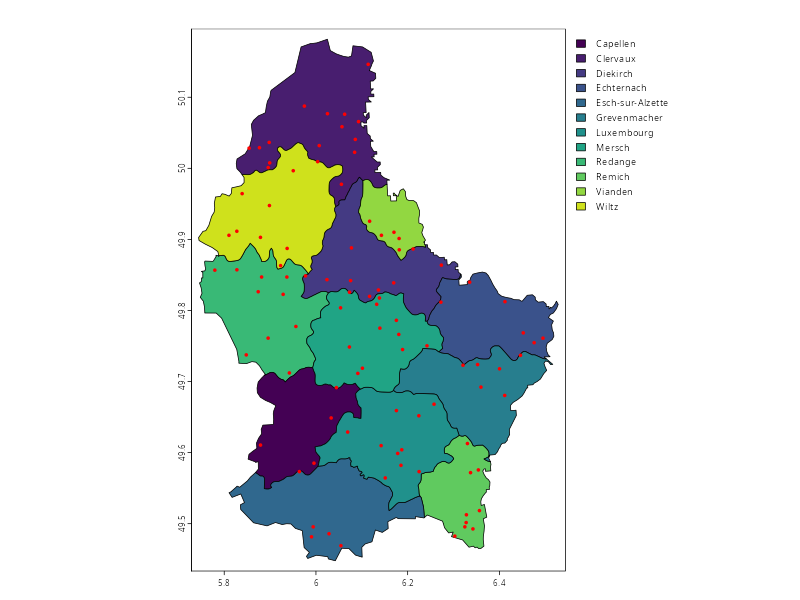

In [79]:
f <- system.file("ex/lux.shp", package="terra")
v <- vect(f)[, c(2, 4)]
p <- spatSample(v, 100)
values(p) <- data.frame(b2 = 1:100, ssep1 = 100:1)

zonal(p, v, mean) |> print()

plot(v, "NAME_2")
points(p, col = "red")

## Situation (spatial context) based methods

### `focal`

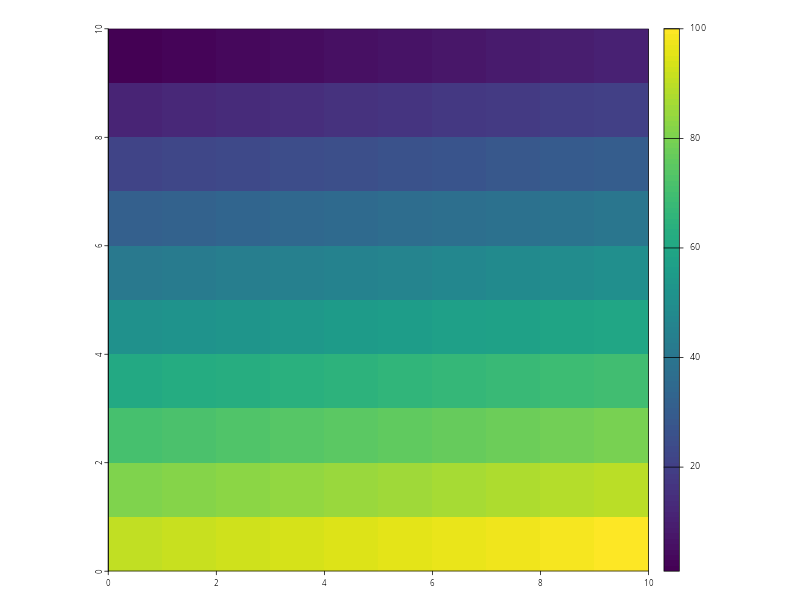

In [86]:
r <- rast(ncols=10, nrows=10, ext(0, 10, 0, 10))
values(r) <- 1:ncell(r)

plot(r)

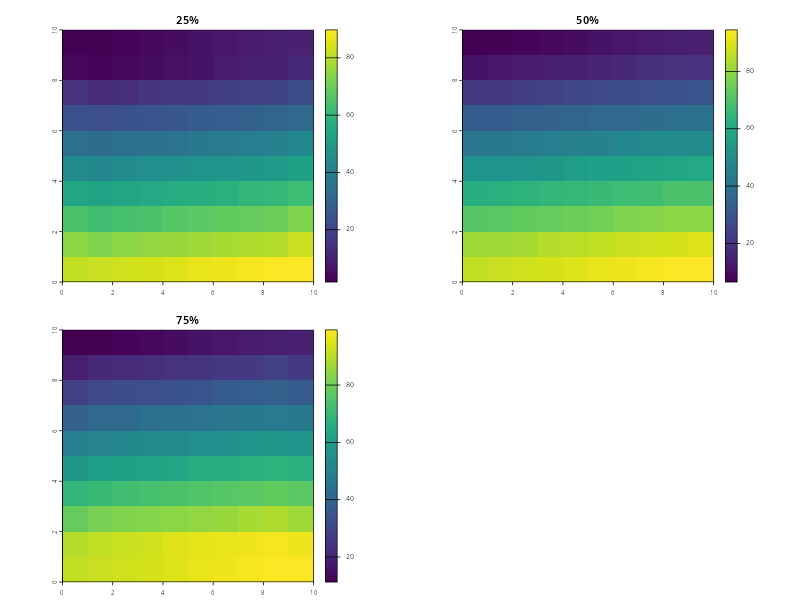

In [87]:
f <- focal(r, w = 3, fun = function(x, ...) quantile(x, c(.25, .5, .75), ...), na.rm = TRUE) 

plot(f)

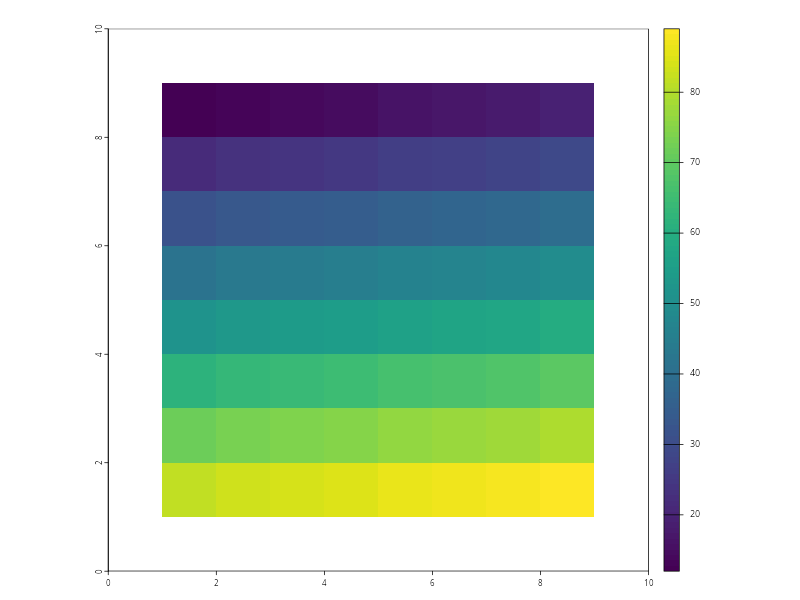

In [88]:
f <- focal(r, w = 3, fun = "mean") 

plot(f)

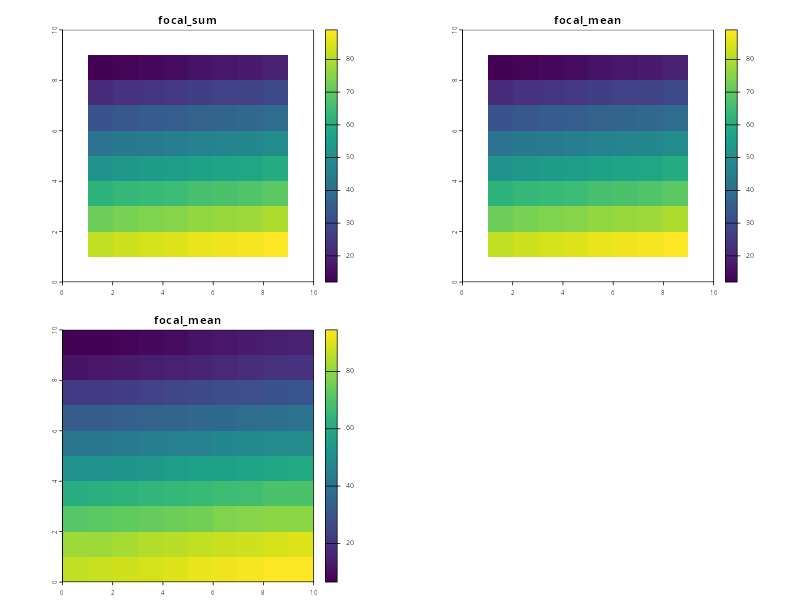

In [92]:
a <- focal(r, w = matrix(1/9, nc = 3, nr = 3))
b <- focal(r, w = 3, fun = mean, na.rm = FALSE)
d <- focal(r, w = 3, fun = mean, na.rm = TRUE)

plot(c(a, b, d))

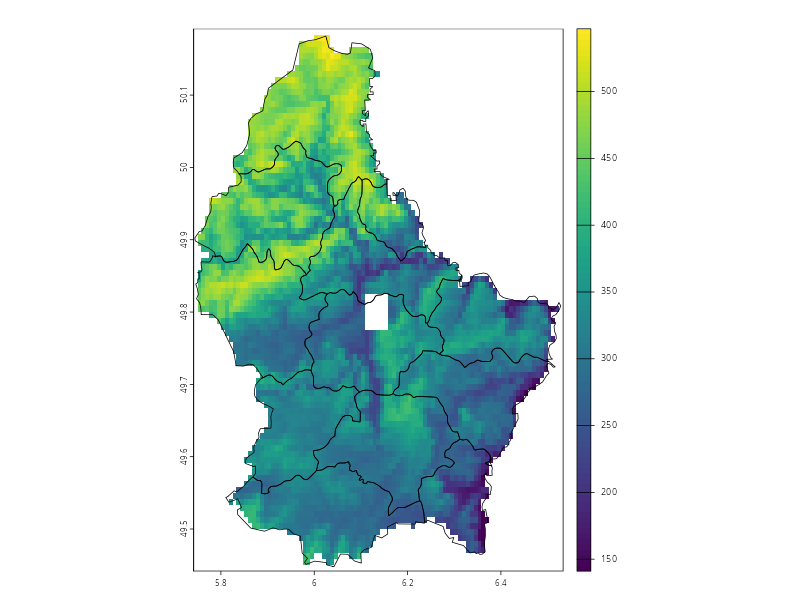

In [97]:
v <- vect(system.file("ex/lux.shp", package = "terra"))
r <- rast(system.file("ex/elev.tif", package = "terra"))
r[45:50, 45:50] <- NA
f <- "sum"

plot(r)
lines(v)

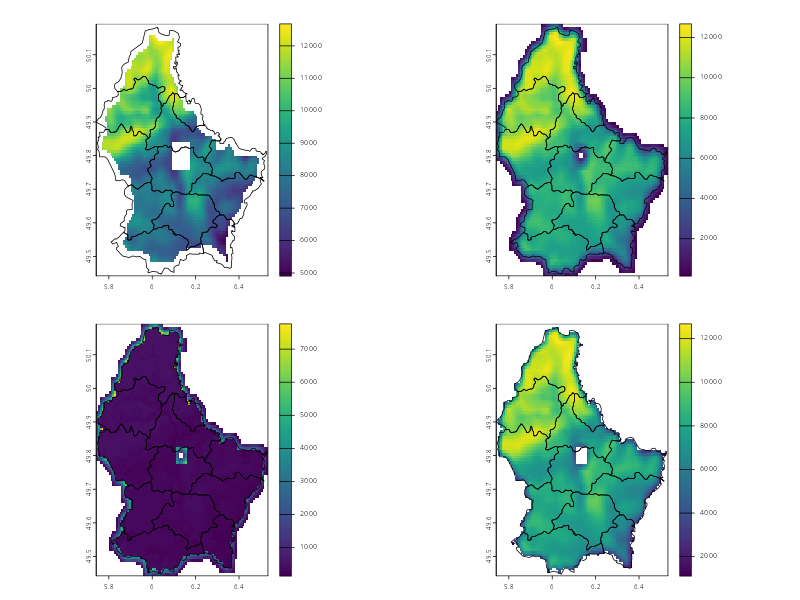

In [103]:
opar <- par(no.readonly = TRUE)
par(mfrow = c(2, 2))
plot(focal(r, 5, f) , fun = lines(v))
plot(focal(r, 5, f, na.rm = TRUE), fun = lines(v))
plot(focal(r, 5, f, na.policy = "only", na.rm = TRUE), fun = lines(v))
plot(focal(r, 5, f, na.policy = "omit", na.rm = TRUE), fun = lines(v))
par(opar)

### `patches`

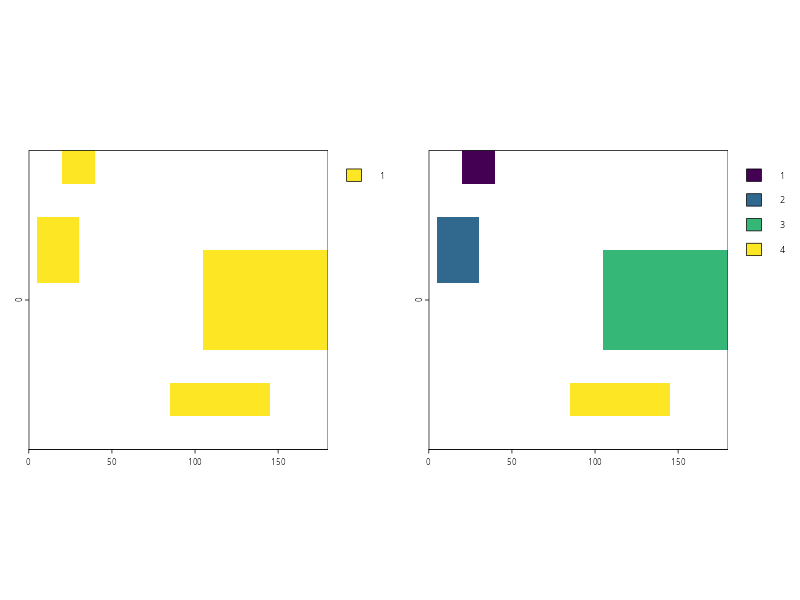

In [105]:
r <- rast(nrows = 18, ncols = 36, xmin = 0)
r[1:2, 5:8] <- 1
r[5:8, 2:6] <- 1
r[7:12, 22:36] <- 1
r[15:16, 18:29] <- 1
p <- patches(r)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r)
plot(p)
par(opar)

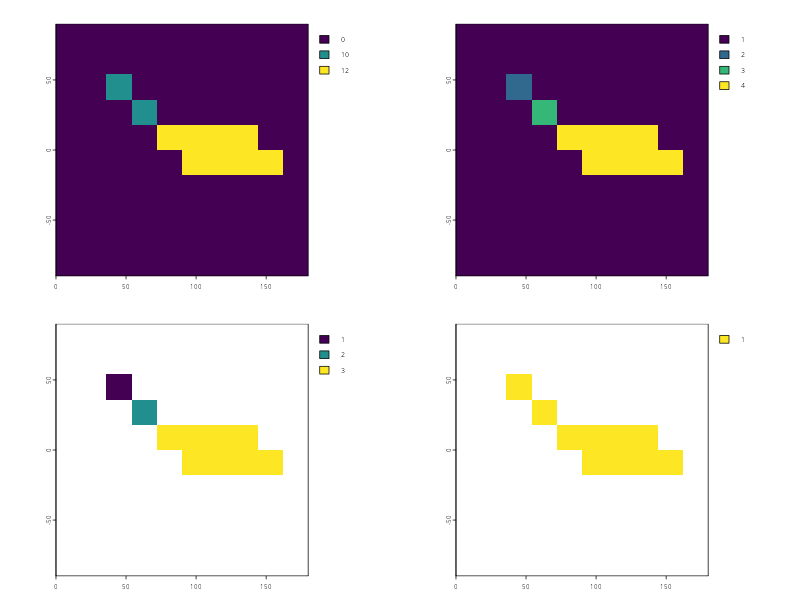

In [111]:
r <- rast(nrows = 10, ncols = 10, xmin = 0, vals = 0)
r[3, 3] <- 10
r[4, 4] <- 10
r[5, 5:8] <- 12
r[6, 6:9] <- 12

p <- patches(r, values = TRUE)
p4 <- patches(r, zeroAsNA = TRUE)
p8 <- patches(r, 8, zeroAsNA = TRUE)

opar <- par(no.readonly = TRUE)
par(mfrow = c(2, 2))
plot(r)
plot(p)
plot(p4)
plot(p8)
par(opar)

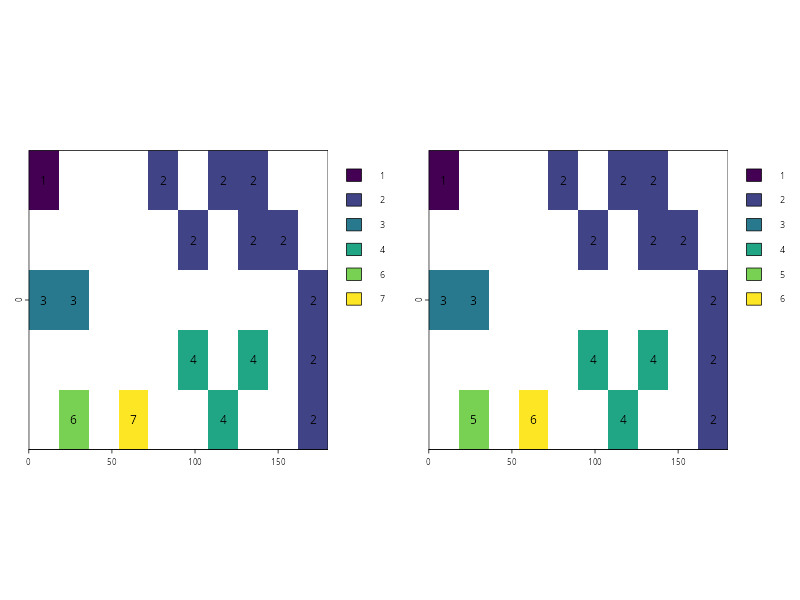

In [114]:
r <- rast(nrows = 5, ncols = 10, xmin = 0)
set.seed(0)
values(r)<- round(runif(ncell(r)) * 0.7)
rp1 <- patches(r, directions = 8, zeroAsNA = TRUE)
rp2 <- patches(r, directions = 8, zeroAsNA = TRUE, allowGaps = FALSE) 

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(rp1, type = "classes") ; text(rp1)
plot(rp2, type = "classes") ; text(rp2)
par(opar)

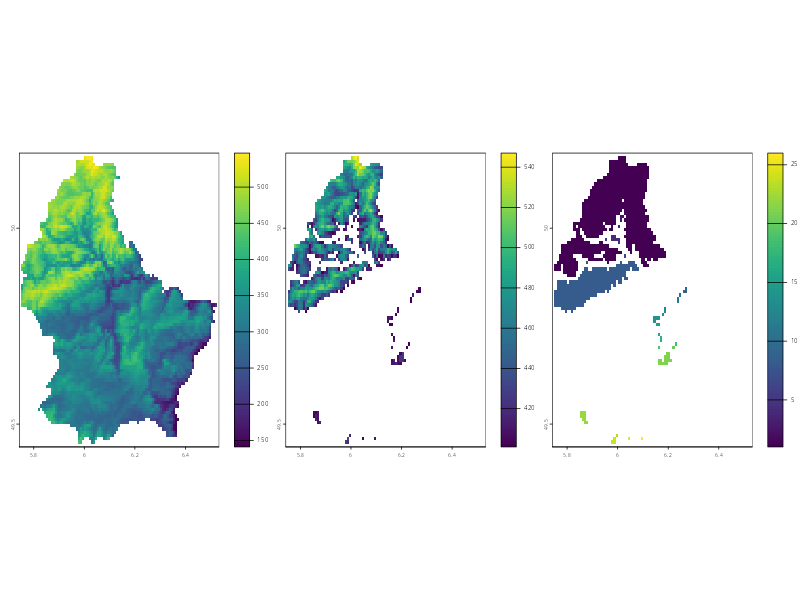

In [115]:
f <- system.file("ex/elev.tif", package = "terra")
r <- rast(f)
x <- classify(r, cbind(-Inf, 400, NA))
y <- patches(x)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 3))
plot(r)
plot(x)
plot(y)
par(opar)

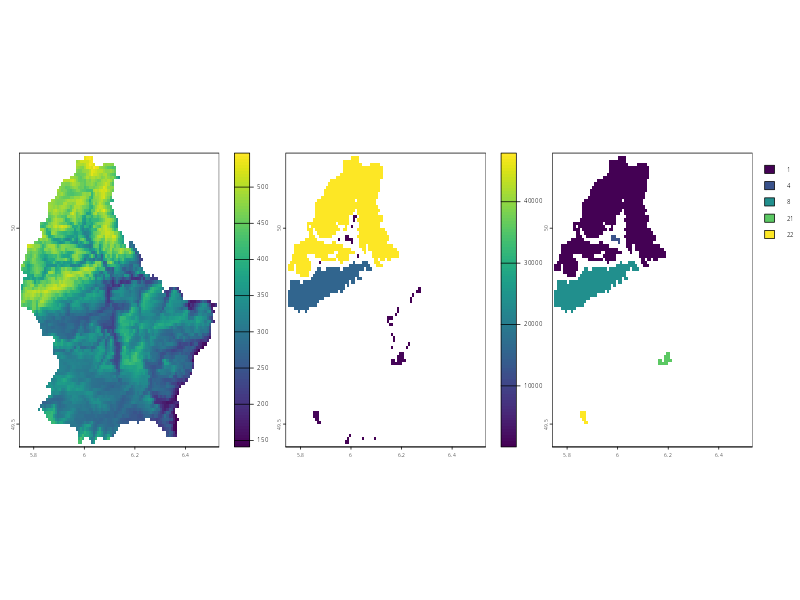

In [117]:
rz <- zonal(cellSize(y, unit = "ha"), y, sum, as.raster = TRUE)
s <- ifel(rz < 250, NA, y)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 3))
plot(r)
plot(rz)
plot(s)
par(opar)

### `terrain`

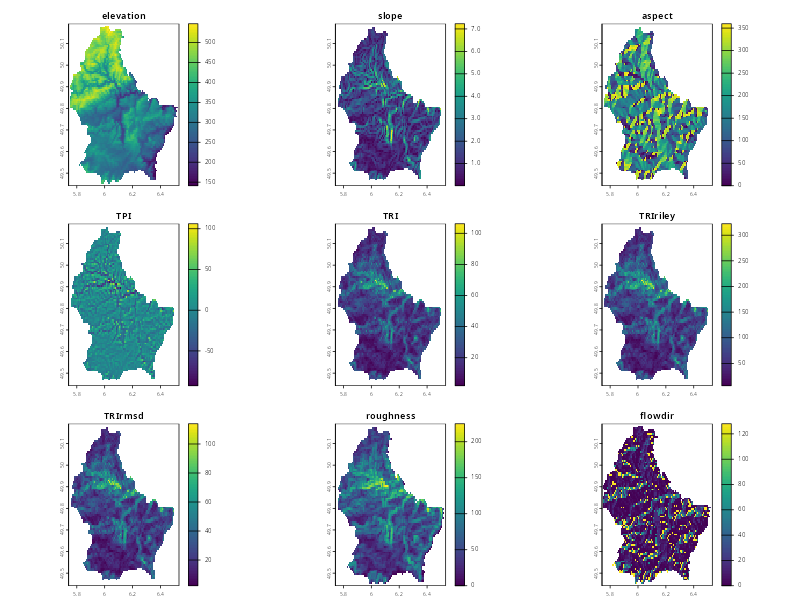

In [ ]:
f <- system.file("ex/elev.tif", package="terra")
r <- rast(f)

rs <- terrain(r, "slope")
ra <- terrain(r, "aspect")
rp <- terrain(r, "TPI")
ri <- terrain(r, "TRI")
rr <- terrain(r, "TRIriley")
rm <- terrain(r, "TRIrmsd")
ro <- terrain(r, "roughness")
rf <- terrain(r, "flowdir")

# slope, aspect, TPI, TRI, TRIriley, TRIrmsd, roughness, flowdir
plot(c(r, rs, ra, rp, ri, rr, rm, ro, rf))

## Accessing cell values

### `extract`

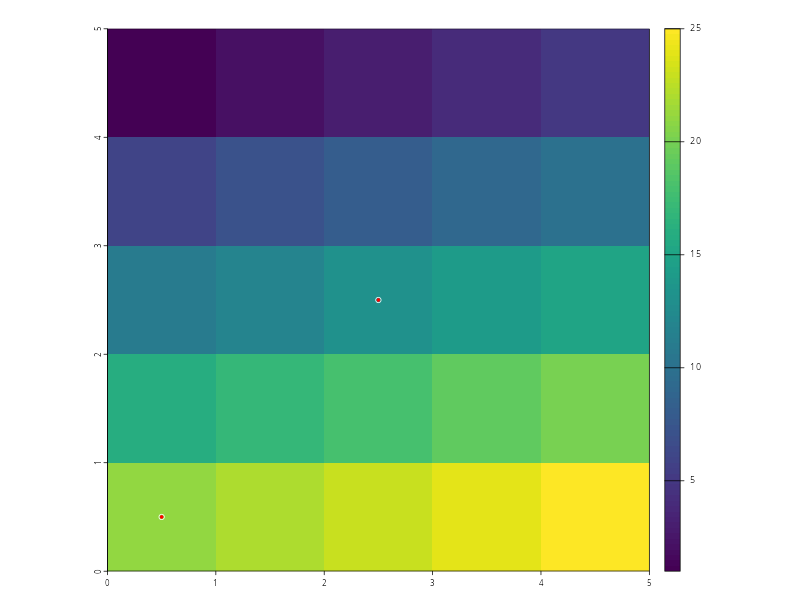

In [131]:
r <- rast(ncols = 5, nrows = 5, xmin = 0, xmax = 5, ymin = 0, ymax = 5)
values(r) <- 1:25
xy <- rbind(c(0.5, 0.5), c(2.5, 2.5))
p <- vect(xy, crs = "+proj=longlat +datum=WGS84")

plot(r)
points(xy, col = "white")
points(p, col = "red")

In [132]:
extract(r, xy) |> print()

  lyr.1
1    21
2    13


In [133]:
extract(r, p) |> print()

  ID lyr.1
1  1    21
2  2    13


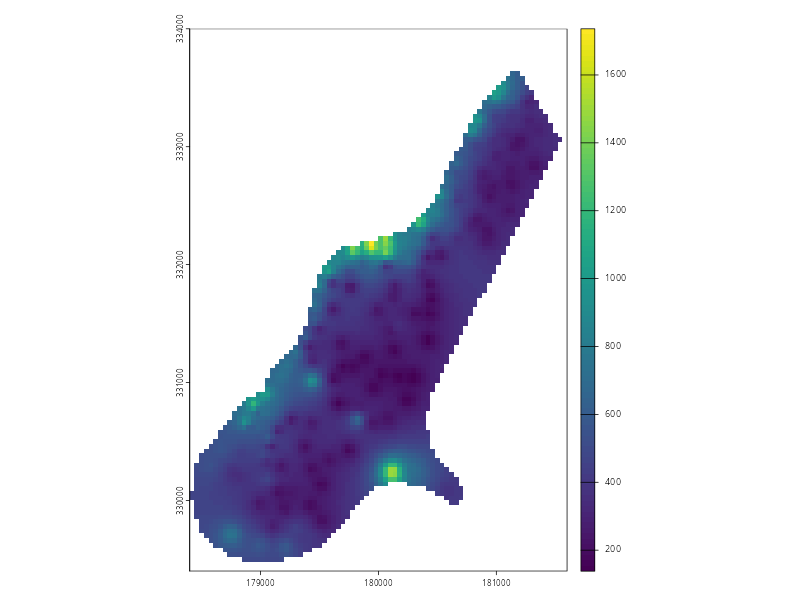

In [134]:
f <- system.file("ex/meuse.tif", package = "terra")
r <- rast(f)

plot(r)

In [ ]:
xy <- cbind(179000, 330000)
xy <- rbind(xy - 100, xy, xy + 1000)
extract(r, xy) |> print()

  meuse
1   378
2   251
3   208


In [137]:
p <- vect(xy)
g <- geom(p)
extract(r, p) |> print()

  ID meuse
1  1   378
2  2   251
3  3   208


In [138]:
x <- r + 10
extract(x, p) |> print()

  ID meuse
1  1   388
2  2   261
3  3   218


In [139]:
i <- cellFromXY(r, xy)
x[i]
r[i]

  meuse
1   378
2   251
3   208

In [140]:
y <- c(x, x * 2, x * 3)
y[i]

  meuse meuse meuse
1   388   776  1164
2   261   522   783
3   218   436   654

  ID elevation
1  1  467.1052
2  2  333.8629


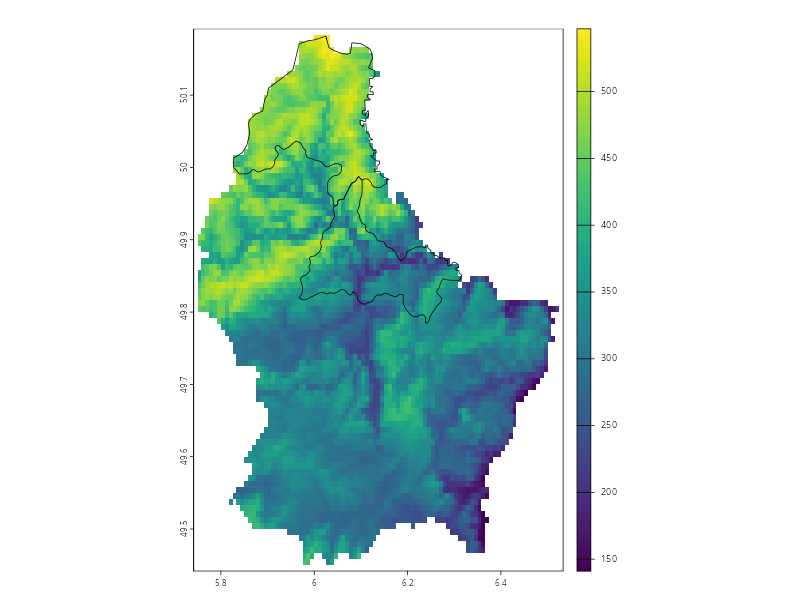

In [143]:
f <- system.file("ex/lux.shp", package = "terra")
v <- vect(f)
v <- v[1:2,]
rf <- system.file("ex/elev.tif", package = "terra")
x <- rast(rf)

extract(x, v, mean, na.rm = TRUE) |> print()
plot(x)
lines(v)

  ID test
1  1    2
2  1    3
3  1    6
4  1    7
5  1    8
6  2   13
7  2   17
8  2   18
9  2   19


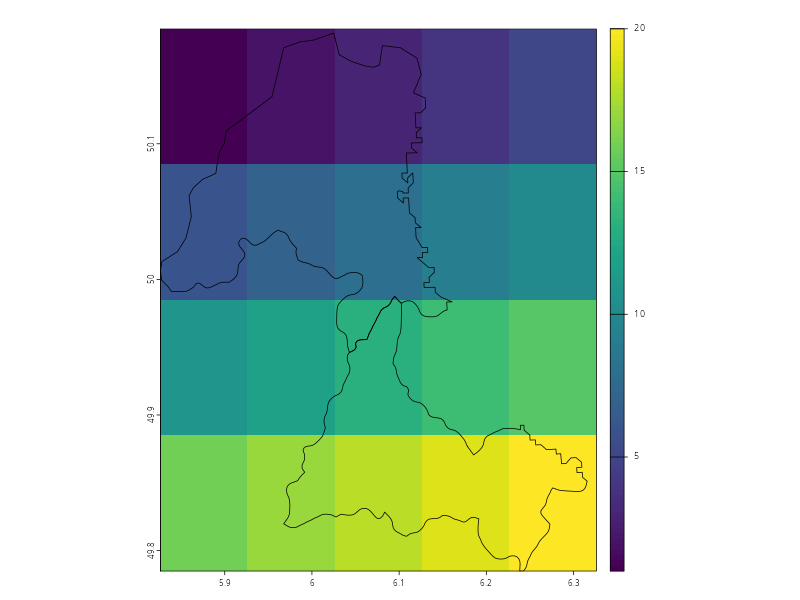

In [151]:
z <- rast(v, resolution = .1, names = "test")
values(z) <- 1:ncell(z)

e <- extract(z, v, ID = TRUE)
print(e)

plot(z)
lines(v)

In [152]:
tapply(e[,2], e[,1], mean, na.rm = TRUE) |> print()

    1     2 
 5.20 16.75 


In [153]:
x <- c(z, z * 2, z / 3)
names(x) <- letters[1:3]

e <- extract(x, v, ID = TRUE)
de <- data.frame(e)
print(de)

  ID  a  b         c
1  1  2  4 0.6666667
2  1  3  6 1.0000000
3  1  6 12 2.0000000
4  1  7 14 2.3333333
5  1  8 16 2.6666667
6  2 13 26 4.3333333
7  2 17 34 5.6666667
8  2 18 36 6.0000000
9  2 19 38 6.3333333


In [154]:
aggregate(de[, 2:4], de[, 1, drop = FALSE], mean) |> print()

  ID     a    b        c
1  1  5.20 10.4 1.733333
2  2 16.75 33.5 5.583333


### `spatSample`

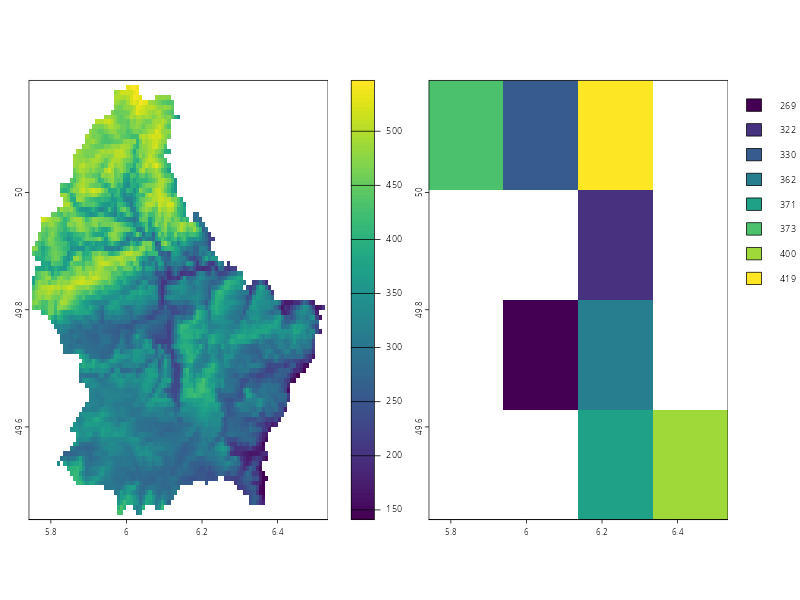

In [160]:
f <- system.file("ex/elev.tif", package = "terra")
r <- rast(f)
s <- spatSample(r, 10, as.raster = TRUE)

opar <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))
plot(r)
plot(s)
par(opar)

In [161]:
spatSample(r, 5)

  elevation
1        NA
2       316
3        NA
4       346
5       455

In [162]:
spatSample(r, 5, na.rm = TRUE)

  elevation
1       356
2       385
3       331
4       303
5       376

In [163]:
spatSample(r, 5, "regular")

  elevation
1       479
2       NaN
3       NaN
4       419
5       290
6       306
7       281
8       286
9       NaN

In [164]:
size <- 6
spatSample(r, 6, "random", cells = TRUE, xy = TRUE, values = FALSE)

     cell        x        y
[1,] 4810 6.237500 49.77083
[2,] 1861 6.204167 50.02917
[3,]  999 6.145833 50.10417
[4,] 4990 6.154167 49.75417
[5,] 8071 6.495833 49.48750
[6,] 5612 5.795833 49.69583

In [165]:
spatSample(r, 6, "regular", cells = TRUE, xy = TRUE)

  cell        x        y elevation
1 7458 6.137500 49.53750       264
2 7505 6.529167 49.53750        NA
3 7411 5.745833 49.53750        NA
4 5368 6.137500 49.72083       289
5 5415 6.529167 49.72083        NA
6 5321 5.745833 49.72083        NA
7 3183 6.137500 49.91250       322
8 1093 6.137500 50.09583        NA

In [166]:
rr <- rast(ncol = 10, nrow = 10, names = "stratum")
set.seed(1)
values(rr) <- round(runif(ncell(rr), 1, 3))
spatSample(rr, 2, "stratified", xy = TRUE)

        x   y stratum
[1,] -162 -81       1
[2,]  -54  45       1
[3,] -126 -27       2
[4,]   90 -81       2
[5,] -162   9       3
[6,]   54  27       3

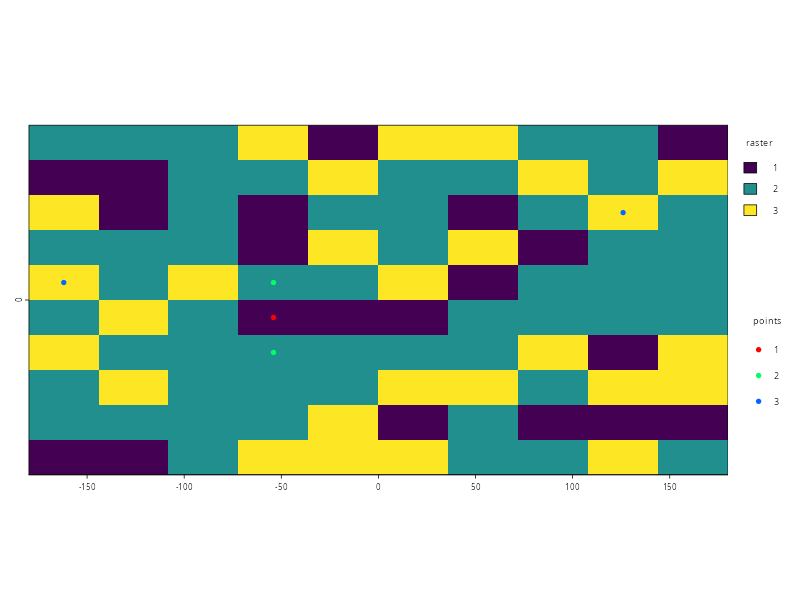

In [167]:
s <- spatSample(rr, 5, "stratified", as.points = TRUE, each = FALSE)
plot(rr, plg=list(title="raster"))
plot(s, 1, add = TRUE, plg = list(x = 185, y = 1, title = "points"), col = rainbow(5))

In [168]:
e <- ext(r)
spatSample(e, 10, "random", lonlat = TRUE)

             x        y
 [1,] 6.357709 49.52934
 [2,] 6.021621 49.46180
 [3,] 6.047319 49.83182
 [4,] 6.124904 49.65330
 [5,] 6.344043 49.92022
 [6,] 5.938780 49.68683
 [7,] 6.290630 49.97649
 [8,] 6.321464 50.02292
 [9,] 5.862387 50.16090
[10,] 6.175421 49.92543

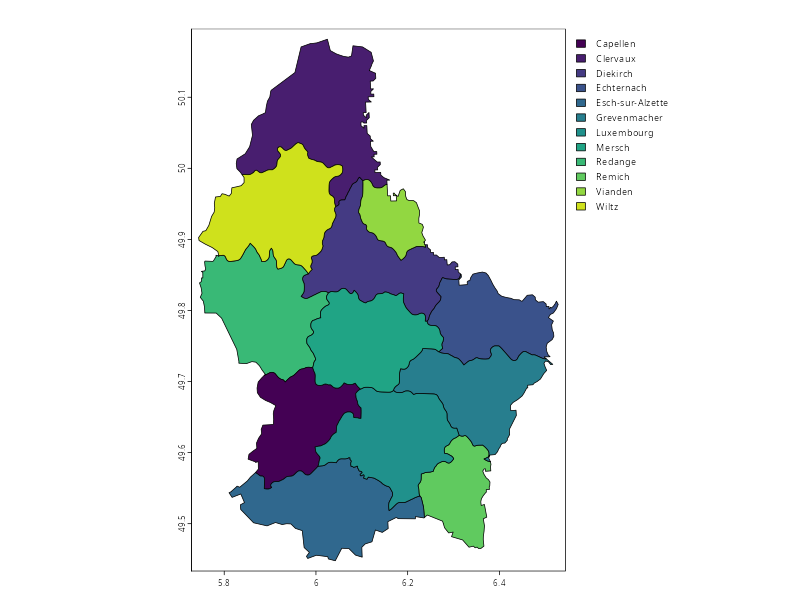

In [172]:
f <- system.file("ex/lux.shp", package = "terra")
v <- vect(f)

plot(v, "NAME_2")

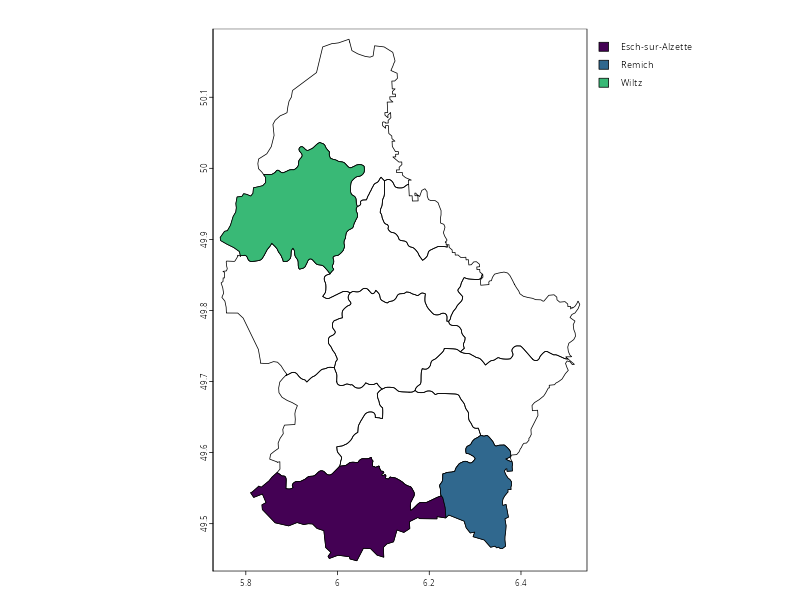

In [182]:
plot(v)
plot(sample(v, 3), "NAME_2", add = TRUE)

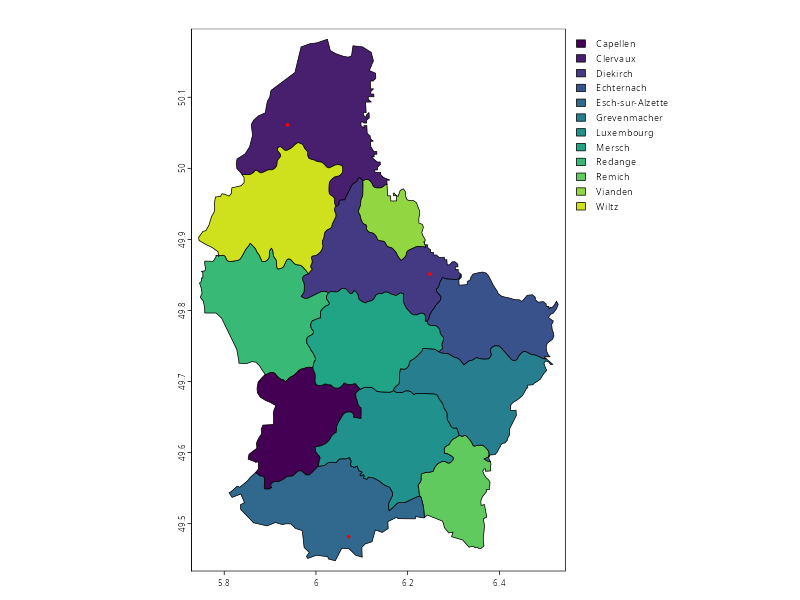

In [179]:
p <- spatSample(v, 3)
plot(v, "NAME_2")
points(p, col = "red")